In [178]:
# test a bunch of pickers on raw waveform, filtered waveform, spectrograms.
# get ready to retrain a picker. 
# then we need to find a way to locate them. 

import pandas as pd
import numpy as np
import h5py
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Optional, List, Tuple, Dict, Any


In [179]:
# extracting the catalog
comcat_file_csv = pd.read_csv("/data/whd02/niyiyu_data/PNWML/comcat/metadata.csv")
exotic_file_csv = pd.read_csv("/data/whd02/niyiyu_data/PNWML/exotic/metadata.csv")
noise_file_csv = pd.read_csv("/data/whd02/niyiyu_data/PNWML/noise/metadata.csv")



# extracting the metadata corresponding to individual events
cat_exp = comcat_file_csv[comcat_file_csv['source_type'] == 'explosion']
cat_eq = comcat_file_csv[comcat_file_csv['source_type'] == 'earthquake']
cat_no = noise_file_csv
cat_su = exotic_file_csv[exotic_file_csv['source_type'] == 'surface event']

In [180]:
base_path = Path("/data/whd02/niyiyu_data/PNWML")
file_paths = {
    "noise": {
        "csv": base_path / "noise/metadata.csv",
        "hdf5": base_path / "noise/waveforms.hdf5",
        "waveform_len": 15000
    },
    "comcat": {
        "csv": base_path / "comcat/metadata.csv",
        "hdf5": base_path / "comcat/waveforms.hdf5",
        "waveform_len": 15000
    },
    "exotic": {
        "csv": base_path / "exotic/metadata.csv",
        "hdf5": base_path / "exotic/waveforms.hdf5",
        "waveform_len": 18000
    }
}

In [181]:
cat_su

,event_id,source_type,station_network_code,station_channel_code,station_code,station_location_code,station_latitude_deg,station_longitude_deg,station_elevation_m,trace_name,trace_sampling_rate_hz,trace_start_time,trace_S_arrival_sample,trace_S_onset,trace_P_arrival_sample,trace_P_onset,trace_snr_db
355,pnsn3179368,surface event,UW,HH,RCM,--,46.836,-121.733,3085.0,"bucket1$0,:3,:18001",100,2021-12-22T04:48:25.000000Z,NaN,NaN,7000.0,emergent,6.493|2.298|0.447
356,pnsn3179093,surface event,CC,BH,VALT,--,46.214,-122.189,1681.0,"bucket1$1,:3,:18001",100,2021-12-19T07:31:56.000000Z,NaN,NaN,7000.0,emergent,-2.019|1.492|-1.325
357,pnsn3179088,surface event,CC,BH,HOA,--,46.242,-122.192,1151.0,"bucket1$2,:3,:18001",100,2021-12-19T07:27:38.000000Z,NaN,NaN,7000.0,emergent,6.657|-3.429|8.158
358,pnsn3178938,surface event,UW,HH,RCM,--,46.836,-121.733,3085.0,"bucket1$3,:3,:18001",100,2021-12-17T16:47:57.000000Z,NaN,NaN,7000.0,emergent,10.592|16.458|17.760
359,pnsn3177563,surface event,CC,BH,SEP,--,46.200,-122.191,2114.0,"bucket1$4,:3,:18001",100,2021-12-07T09:43:06.000000Z,NaN,NaN,7000.0,emergent,-0.222|6.356|2.264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9262,pnsn830593,surface event,UW,EH,EDM,--,46.197,-122.151,1609.0,"bucket1$8993,:3,:18001",100,2002-01-02T17:37:11.000000Z,NaN,NaN,7000.0,impulsive,nan|nan|-1.162
9263,pnsn830593,surface event,UW,EH,YEL,--,46.209,-122.189,1750.0,"bucket1$8994,:3,:18001",100,2002-01-02T17:37:09.000000Z,NaN,NaN,7000.0,impulsive,nan|nan|14.469
9264,pnsn830593,surface event,UW,EH,SEP,--,46.200,-122.191,2116.0,"bucket1$8995,:3,:18001",100,2002-01-02T17:37:09.000000Z,NaN,NaN,7000.0,impulsive,nan|nan|4.575
9265,pnsn829903,surface event,UW,EH,YEL,--,46.209,-122.189,1750.0,"bucket1$8996,:3,:18001",100,2002-01-01T21:33:40.000000Z,NaN,NaN,7000.0,impulsive,nan|nan|12.728


In [182]:
# Top 10 event_ids by number of rows
top10 = (
  cat_su.groupby("event_id")
      .size()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name="n_rows")
)

print(top10)  # columns: event_id, n_rows


      event_id  n_rows
0  pnsn1788048      16
1  pnsn1767548      15
2  pnsn2196563      15
3  pnsn1769043      13
4  pnsn3168133      13
5   pnsn957323      12
6  pnsn1123903      12
7  pnsn2178678      12
8  pnsn3087778      11
9  pnsn1476643      11


In [238]:
hdf5_path = file_paths['exotic']['hdf5']
f = h5py.File(hdf5_path)
z_data = f['/data/bucket1'][3, 2, :]


(6800.0, 7500.0)

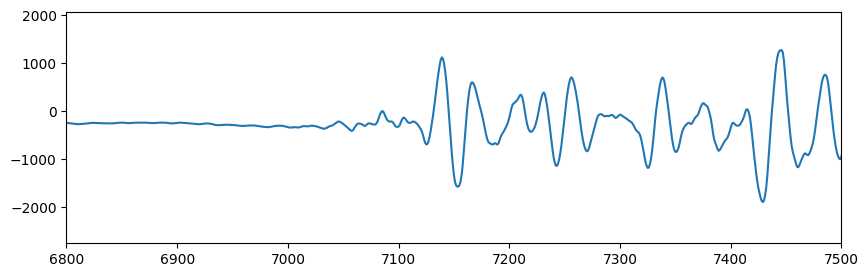

In [239]:
plt.figure(figsize = [10,3])
plt.plot(z_data)
plt.xlim(6800, 7500)

In [240]:
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks


# ----------------------------
# Utilities
# ----------------------------
def bandpass(x: np.ndarray, fs: float, fmin: float, fmax: float, order: int = 3) -> np.ndarray:
    """Zero-phase Butterworth bandpass."""
    x = np.asarray(x, dtype=float)
    nyq = 0.5 * fs
    fmin = max(1e-6, float(fmin))
    fmax = min(float(fmax), nyq - 1e-6)
    if fmin >= fmax:
        return x.copy()
    b, a = butter(order, [fmin / nyq, fmax / nyq], btype="band")
    return filtfilt(b, a, x)


def moving_average(x: np.ndarray, win: int) -> np.ndarray:
    """Centered moving average with reflect padding."""
    x = np.asarray(x, dtype=float)
    if win <= 1:
        return x.copy()
    w = np.ones(win, dtype=float) / float(win)
    pad = win // 2
    xp = np.pad(x, (pad, pad), mode="reflect")
    y = np.convolve(xp, w, mode="valid")
    return y[: x.size]


# ----------------------------
# Rolling kurtosis (central moments) = Eq (8)-(10) style
# ----------------------------
def rolling_kurtosis_trailing(x: np.ndarray, win: int) -> np.ndarray:
    """
    Trailing-window kurtosis (NOT excess):
      K = mu4 / mu2^2
    computed on window x[k-win+1 : k+1].

    Output aligned to original indices: first win-1 values are NaN.
    O(n) via cumulative sums of powers.
    """
    x = np.asarray(x, dtype=float)
    n = x.size
    out = np.full(n, np.nan, dtype=float)
    if win < 4 or win > n:
        return out

    x1 = x
    x2 = x1 * x1
    x3 = x2 * x1
    x4 = x2 * x2

    c1 = np.cumsum(x1)
    c2 = np.cumsum(x2)
    c3 = np.cumsum(x3)
    c4 = np.cumsum(x4)

    def wsum(c):
        return c[win - 1:] - np.concatenate(([0.0], c[:-win]))

    S1 = wsum(c1)
    S2 = wsum(c2)
    S3 = wsum(c3)
    S4 = wsum(c4)

    N = float(win)
    m1 = S1 / N
    ex2 = S2 / N
    ex3 = S3 / N
    ex4 = S4 / N

    mu2 = ex2 - m1**2
    # E[(x-m)^4] = E[x^4] -4mE[x^3] +6m^2E[x^2] -4m^3E[x] + m^4
    mu4 = ex4 - 4*m1*ex3 + 6*(m1**2)*ex2 - 4*(m1**3)*m1 + (m1**4)

    eps = 1e-12
    K = mu4 / np.maximum(mu2, eps) ** 2
    out[win - 1:] = K
    return out


# ----------------------------
# APP transformations: F1 -> F2 -> F3 -> F4
# ----------------------------
def f1_to_f2(F1: np.ndarray) -> np.ndarray:
    """
    Eq (11) logic from your screenshot:
      F2(1)=F1(1)
      F2(k+1)=F2(k)+delta(k)*dF1(k)
      delta=1 if dF1>=0 else 0
    """
    F1 = np.asarray(F1, dtype=float)
    F2 = np.full_like(F1, np.nan)
    finite = np.isfinite(F1)
    if not np.any(finite):
        return F2

    idx = np.where(finite)[0]
    start = idx[0]

    F2[start] = F1[start]
    d = np.diff(F1[start:])
    d = np.where(np.isfinite(d), d, 0.0)
    inc = np.maximum(d, 0.0)
    F2[start + 1 : start + 1 + inc.size] = F2[start] + np.cumsum(inc)
    return F2


def f2_to_f3(F2: np.ndarray) -> np.ndarray:
    """
    Detrend endpoints:
      F3(k) = F2(k) - [a*(k-1)+b]
      a=(F2(n)-F2(1))/(n-1), b=F2(1)
    (Implemented over the finite span.)
    """
    F2 = np.asarray(F2, dtype=float)
    F3 = F2.copy()
    idx = np.where(np.isfinite(F2))[0]
    if idx.size < 2:
        return F3

    i0, i1 = idx[0], idx[-1]
    b = F2[i0]
    a = (F2[i1] - F2[i0]) / float(i1 - i0)

    k = np.arange(i0, i1 + 1, dtype=float)
    line = a * (k - i0) + b
    F3[i0 : i1 + 1] = F2[i0 : i1 + 1] - line
    return F3


def f3_to_f4(F3: np.ndarray, min_peak_distance: int = 1) -> np.ndarray:
    """
    Implements the paper's idea:
      T(k) = F3(k) - M_{i+1} for k in (s_i, s_{i+1}]
      F4(k) = T(k) if T(k)<0 else 0
    where M_i are local maxima of F3 at indices s_i.
    """
    F3 = np.asarray(F3, dtype=float)
    F4 = np.full_like(F3, np.nan)

    finite = np.isfinite(F3)
    if np.sum(finite) < 10:
        return F4

    x = F3.copy()
    x[~finite] = np.nanmin(x[finite])

    peaks, _ = find_peaks(x, distance=max(1, int(min_peak_distance)))
    if peaks.size == 0:
        # If no peaks, just clamp positives to 0 (still yields negative dips if any)
        tmp = np.minimum(F3, 0.0)
        F4[np.isfinite(tmp)] = tmp[np.isfinite(tmp)]
        return F4

    M = x[peaks]  # peak heights

    # for each k, find the first peak index >= k (the "next maximum")
    next_peak_idx = np.searchsorted(peaks, np.arange(len(x)), side="left")
    next_peak_idx = np.clip(next_peak_idx, 0, peaks.size - 1)
    next_max = M[next_peak_idx]

    T = F3 - next_max
    F4 = np.where(np.isfinite(T), np.minimum(T, 0.0), np.nan)  # keep negatives, else 0
    return F4


# ----------------------------
# Picking on F4 + long-to-short refinement
# ----------------------------

def minima_indices(
    F4: np.ndarray,
    fs: float,
    min_sep_s: float = 0.5,
    prominence: Optional[float] = None
) -> np.ndarray:
    """
    Minima in F4 are picked by finding peaks in -F4 (because minima are negative dips).
    """
    y = np.asarray(F4, dtype=float)
    if not np.any(np.isfinite(y)):
        return np.array([], dtype=int)

    z = -y
    z[~np.isfinite(z)] = 0.0
    dist = max(1, int(round(min_sep_s * fs)))

    kwargs = {"distance": dist}
    if prominence is not None:
        kwargs["prominence"] = float(prominence)

    pk, _ = find_peaks(z, **kwargs)
    pk = pk[y[pk] < 0]  # ensure it's a negative dip in F4
    return np.sort(pk)


def long_to_short_refinement(
    F3_avg: np.ndarray,
    fs: float,
    smooth_windows_s: List[float],
    min_sep_s: float = 0.5,
    search_radius_s: Optional[float] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    - Smooth F3_avg at multiple scales (largest -> smallest).
    - Compute F4 at each scale.
    - Pick minima on the smoothest F4.
    - Snap those picks to nearest minima at the next (less-smoothed) scale, repeat.
    Returns: refined_pick_indices, F4_at_least_smoothed_scale
    """
    if len(smooth_windows_s) == 0:
        smooth_windows_s = [0.0]
    smooth_windows_s = sorted(smooth_windows_s, reverse=True)

    mins_levels = []
    F4_levels = []

    for sw in smooth_windows_s:
        win = max(1, int(round(sw * fs)))
        F3s = moving_average(F3_avg, win)
        F4s = f3_to_f4(F3s, min_peak_distance=max(1, int(0.1 * fs)))
        mins = minima_indices(F4s, fs, min_sep_s=min_sep_s)
        mins_levels.append(mins)
        F4_levels.append(F4s)

    picks = mins_levels[0].copy()
    if picks.size == 0:
        return picks, F4_levels[-1]

    if search_radius_s is None:
        # half of coarsest smoothing window, but at least 0.5s
        search_radius_s = max(0.5, 0.5 * smooth_windows_s[0])
    R = int(round(search_radius_s * fs))

    for mins in mins_levels[1:]:
        if mins.size == 0:
            continue
        new_picks = []
        for p in picks:
            lo, hi = p - R, p + R
            c = mins[(mins >= lo) & (mins <= hi)]
            if c.size == 0:
                new_picks.append(p)
            else:
                new_picks.append(int(c[np.argmin(np.abs(c - p))]))
        picks = np.array(new_picks, dtype=int)

    picks = np.unique(picks)
    return picks, F4_levels[-1]






# ----------------------------
# Main function: raw waveform -> picks (APP-style, vertical-only)
# ----------------------------
def app_vertical_picker(
    x: np.ndarray,
    fs: float,
    frequency_bands: List[Tuple[float, float]],
    ws_s: List[float],
    smooth_windows_s: List[float],
    *,
    max_picks: int = 2,
    choose: str = "earliest",
    min_sep_s: float = 0.6,
    filter_order: int = 3,
    detrend_mean: bool = True,
    return_debug: bool = False,
):
    """
    APP-style kurtosis picker (Baillard et al. principles) for a SINGLE raw waveform (e.g., vertical).

    What it does:
      1) For each (band, window_size): compute F1(k)=kurtosis, then F2,F3.
      2) Average F3 across all (band x window_size).
      3) Long->short smoothing refinement:
         smooth F3_avg at multiple scales, compute F4, pick minima and snap picks across scales.
      4) Select up to max_picks (either earliest or strongest dips).

    Parameters you asked to control:
      - frequency_bands: list of (fmin, fmax)
      - ws_s: list of kurtosis window sizes in seconds (for F3 averaging)

    Returns:
      picks_idx (np.ndarray), picks_time_s (np.ndarray)
      optionally debug dict with F3_avg and F4_final.
    """
    x = np.asarray(x, dtype=float)
    if detrend_mean:
        x = x - np.nanmean(x)

    # Build all F3s
    F3_list = []
    for fmin, fmax in frequency_bands:
        xf = bandpass(x, fs, fmin, fmax, order=filter_order)
        xf = xf - np.mean(xf)  # helps the kurtosis stability
        for ws in ws_s:
            win = max(4, int(round(ws * fs)))
            F1 = rolling_kurtosis_trailing(xf, win)
            F2 = f1_to_f2(F1)
            F3 = f2_to_f3(F2)
            F3_list.append(F3)

    F3_stack = np.vstack([np.nan_to_num(f, nan=np.nan) for f in F3_list])
    F3_avg = np.nanmean(F3_stack, axis=0)

    # Refinement -> picks on least-smoothed scale
    refined, F4_final = long_to_short_refinement(
        F3_avg, fs, smooth_windows_s=smooth_windows_s, min_sep_s=min_sep_s
    )

    if refined.size == 0:
        if return_debug:
            return np.array([], dtype=int), np.array([], dtype=float), {"F3_avg": F3_avg, "F4_final": F4_final}
        return np.array([], dtype=int), np.array([], dtype=float)

    # Choose picks
    if choose.lower() == "strongest":
        strengths = -F4_final[refined]  # deeper valley = stronger
        order = np.argsort(strengths)[::-1]
        chosen = refined[order][:max_picks]
        chosen = np.sort(chosen)
    else:
        # "earliest" = first arrivals
        chosen = np.sort(refined)[:max_picks]

    picks_t = chosen / float(fs)

    if return_debug:
        dbg = {"F3_avg": F3_avg, "F4_final": F4_final}
        return chosen, picks_t, dbg
    return chosen, picks_t




def rank_minima_by_following_rise(
    minima_idx: np.ndarray,
    F3: np.ndarray,
    fs: float,
    lookahead_s: float = 5.0,
    combine_with_depth: bool = True,
    F4: Optional[np.ndarray] = None,
    depth_weight: float = 0.2,
):
    """
    For each candidate minimum p, compute:
        delta = max(F3[p:p+W]) - F3[p]
    Optionally combine with dip depth in F4:
        score = delta + depth_weight * (-F4[p])

    Returns minima sorted by descending score and arrays of (score, delta, depth).
    """
    minima_idx = np.asarray(minima_idx, dtype=int)
    if minima_idx.size == 0:
        return np.array([], dtype=int), np.array([]), np.array([]), np.array([])

    W = max(1, int(round(lookahead_s * fs)))
    n = len(F3)

    valid_p = []
    scores = []
    deltas = []
    depths = []

    for p in minima_idx:
        if p < 0 or p >= n:
            continue

        hi = min(n, p + W)
        if hi <= p + 1:
            continue

        base = F3[p]
        seg = F3[p:hi]
        if not np.isfinite(base) or not np.any(np.isfinite(seg)):
            continue

        delta = float(np.nanmax(seg) - base)

        depth = 0.0
        if F4 is not None and p < len(F4) and np.isfinite(F4[p]):
            depth = max(0.0, -float(F4[p]))

        score = delta
        if combine_with_depth:
            score = score + float(depth_weight) * depth

        valid_p.append(int(p))
        scores.append(float(score))
        deltas.append(float(delta))
        depths.append(float(depth))

    if len(valid_p) == 0:
        return np.array([], dtype=int), np.array([]), np.array([]), np.array([])

    valid_p = np.asarray(valid_p, dtype=int)
    scores = np.asarray(scores, dtype=float)
    deltas = np.asarray(deltas, dtype=float)
    depths = np.asarray(depths, dtype=float)

    order = np.argsort(scores)[::-1]
    return valid_p[order], scores[order], deltas[order], depths[order]



def app_vertical_picker_with_debug(
    x: np.ndarray,
    fs: float,
    frequency_bands: List[Tuple[float, float]],
    ws_s: List[float],
    smooth_windows_s: List[float],  # kept for compatibility; not used for gating anymore
    *,
    debug_band: Optional[Tuple[float, float]] = None,
    debug_ws_s: Optional[float] = None,
    max_picks: int = 2,
    choose: str = "shape",              # "shape" (recommended), "earliest", "strongest"
    min_sep_s: float = 0.6,
    filter_order: int = 3,
    detrend_mean: bool = True,
    ignore_first_s: float = 5.0,        # helps kill edge artifacts
    lookahead_s: float = 1.0,           # Δ lookahead window for "peak follows dip"
    depth_weight: float = 0.2,          # small weight; Δ is main driver
    return_debug: bool = True,
):
    x = np.asarray(x, dtype=float)
    if detrend_mean:
        x = x - np.nanmean(x)

    if debug_band is None:
        debug_band = frequency_bands[0]
    if debug_ws_s is None:
        debug_ws_s = ws_s[0]

    dbg = {}

    # Build all F3s for averaging
    F3_list = []
    F3_labels = []   # <-- NEW (optional)
    found_debug_pair = False

    for fmin, fmax in frequency_bands:
        xf = bandpass(x, fs, fmin, fmax, order=filter_order)
        xf = xf - np.mean(xf)

        for ws in ws_s:
            win = max(4, int(round(ws * fs)))
            F1 = rolling_kurtosis_trailing(xf, win)
            F2 = f1_to_f2(F1)
            F3 = f2_to_f3(F2)

            F3_list.append(F3)
            F3_labels.append(f"{fmin:g}-{fmax:g} Hz | WS={ws:g} s")  # <-- NEW

            if (fmin, fmax) == tuple(debug_band) and float(ws) == float(debug_ws_s):
                dbg["filtered_example"] = xf
                dbg["F1_example"] = F1
                dbg["F2_example"] = F2
                dbg["F3_example"] = F3
                dbg["debug_band"] = (fmin, fmax)
                dbg["debug_ws_s"] = ws
                found_debug_pair = True

    # <-- NEW: store all F3s ALWAYS (not only in fallback)
    if return_debug:
        dbg["F3_all"] = F3_list
        dbg["F3_labels"] = F3_labels

    # F3 averaged across all band×window settings
    F3_stack = np.vstack([np.nan_to_num(f, nan=np.nan) for f in F3_list])
    F3_avg = np.nanmean(F3_stack, axis=0)

    # If debug pair wasn't matched exactly, compute it once explicitly
    if not found_debug_pair:
        fmin, fmax = debug_band
        xf = bandpass(x, fs, fmin, fmax, order=filter_order)
        xf = xf - np.mean(xf)
        win = max(4, int(round(float(debug_ws_s) * fs)))
        F1 = rolling_kurtosis_trailing(xf, win)
        F2 = f1_to_f2(F1)
        F3 = f2_to_f3(F2)
        dbg["filtered_example"] = xf
        dbg["F1_example"] = F1
        dbg["F2_example"] = F2
        dbg["F3_example"] = F3
        dbg["debug_band"] = (fmin, fmax)
        dbg["debug_ws_s"] = float(debug_ws_s)

    # Compute final F4 from averaged F3
    F4_final = f3_to_f4(F3_avg, min_peak_distance=max(1, int(0.1 * fs)))

    # Candidate minima directly from final F4
    candidates = minima_indices(F4_final, fs, min_sep_s=min_sep_s)

    # Ignore early edge artifacts
    if ignore_first_s is not None and ignore_first_s > 0:
        candidates = candidates[(candidates / float(fs)) >= float(ignore_first_s)]

    # No candidates
    if candidates.size == 0:
        picks_idx = np.array([], dtype=int)
        picks_t = np.array([], dtype=float)
        if return_debug:
            dbg.update({
                "raw": x,
                "F3_avg": F3_avg,
                "F4_final": F4_final,
                "candidates": candidates,
                "ranked": np.array([], dtype=int),
                "scores": np.array([]),
                "deltas": np.array([]),
                "depths": np.array([]),
                "picks_idx": picks_idx,
                "picks_t": picks_t,
            })
            return picks_idx, picks_t, dbg
        return picks_idx, picks_t

    # earliest
    if choose.lower() == "earliest":
        picks_idx = np.sort(candidates)[:max_picks]
        picks_t = picks_idx / float(fs)
        if return_debug:
            dbg.update({
                "raw": x,
                "F3_avg": F3_avg,
                "F4_final": F4_final,
                "candidates": candidates,
                "ranked": np.sort(candidates),
                "scores": np.array([]),
                "deltas": np.array([]),
                "depths": np.array([]),
                "picks_idx": picks_idx,
                "picks_t": picks_t,
            })
            return picks_idx, picks_t, dbg
        return picks_idx, picks_t

    # strongest (by F4 depth only)
    if choose.lower() == "strongest":
        strengths = -F4_final[candidates]
        order = np.argsort(strengths)[::-1]
        ranked = candidates[order]
        picks_idx = np.sort(ranked[:max_picks])
        picks_t = picks_idx / float(fs)
        if return_debug:
            dbg.update({
                "raw": x,
                "F3_avg": F3_avg,
                "F4_final": F4_final,
                "candidates": candidates,
                "ranked": ranked,
                "scores": strengths[order],
                "deltas": np.array([]),
                "depths": np.maximum(0.0, strengths[order]),
                "picks_idx": picks_idx,
                "picks_t": picks_t,
            })
            return picks_idx, picks_t, dbg
        return picks_idx, picks_t

    # shape (recommended): Δ lookahead on F3_avg (+ small depth term)
    ranked, scores, deltas, depths = rank_minima_by_following_rise(
        candidates,
        F3_avg,
        fs,
        lookahead_s=lookahead_s,
        combine_with_depth=True,
        F4=F4_final,
        depth_weight=depth_weight,
    )

    if ranked.size == 0:
        picks_idx = np.array([], dtype=int)
        picks_t = np.array([], dtype=float)
    else:
        picks_idx = np.sort(ranked[:max_picks])
        picks_t = picks_idx / float(fs)

    if return_debug:
        dbg.update({
            "raw": x,
            "F3_avg": F3_avg,
            "F4_final": F4_final,
            "candidates": candidates,
            "ranked": ranked,
            "scores": scores,
            "deltas": deltas,
            "depths": depths,
            "ignore_first_s": ignore_first_s,
            "lookahead_s": lookahead_s,
            "depth_weight": depth_weight,
            "choose": choose,
            "picks_idx": picks_idx,
            "picks_t": picks_t,
        })
        return picks_idx, picks_t, dbg

    return picks_idx, picks_t








def plot_app_debug(dbg, fs, xlim_s=None, title_prefix="APP debug", show_all_f3=True):
    """
    Plot waveform and CF curves stacked:
      1) raw waveform
      2) filtered waveform (example band)
      3) F1 (example)
      4) F2 (example)
      5) ALL F3s used for averaging (faint) + F3_example + F3_avg (bold)
      6) F4_final
    with vertical lines at picks.
    """
    t = np.arange(len(dbg["raw"])) / float(fs)
    picks_t = np.asarray(dbg.get("picks_t", []), dtype=float)

    fig, axes = plt.subplots(6, 1, figsize=(12, 12), sharex=True)

    def vlines(ax):
        for pt in picks_t:
            ax.axvline(pt, linestyle="--", linewidth=1.2)

    # 1) raw waveform
    axes[0].plot(t, dbg["raw"], lw=0.8)
    vlines(axes[0])
    axes[0].set_ylabel("raw")
    axes[0].set_title(f"{title_prefix} | picks={np.round(picks_t, 3)} s")

    # 2) filtered example waveform
    band = dbg.get("debug_band", ("?", "?"))
    ws = dbg.get("debug_ws_s", "?")
    axes[1].plot(t, dbg["filtered_example"], lw=0.8)
    vlines(axes[1])
    axes[1].set_ylabel(f"filt {band}\nws={ws}s")

    # 3) F1 example
    axes[2].plot(t, dbg["F1_example"], lw=0.9)
    vlines(axes[2])
    axes[2].set_ylabel("F1\n(kurt)")

    # 4) F2 example
    axes[3].plot(t, dbg["F2_example"], lw=0.9)
    vlines(axes[3])
    axes[3].set_ylabel("F2")

    # 5) ALL F3s + F3_example + F3_avg
    # Expect dbg to contain:
    #   - "F3_all": list of np.ndarray OR (n_curves, n_samples) array
    #   - optionally "F3_labels": list of strings (same length as F3_all)
    ax = axes[4]

    if show_all_f3 and "F3_all" in dbg and dbg["F3_all"] is not None:
        F3_all = dbg["F3_all"]
        if isinstance(F3_all, list):
            F3_all_arr = np.vstack(F3_all)
        else:
            F3_all_arr = np.asarray(F3_all)

        # Plot all curves faintly
        for k in range(F3_all_arr.shape[0]):
            ax.plot(t, F3_all_arr[k], lw=0.6, alpha=0.15)

    # Overlay example + average
    ax.plot(t, dbg["F3_example"], lw=1.0, alpha=0.9, label="F3 example")
    ax.plot(t, dbg["F3_avg"], lw=1.2, alpha=0.95, label="F3 avg")
    vlines(ax)
    ax.set_ylabel("F3")
    ax.legend(loc="upper right")

    # 6) F4 final
    axes[5].plot(t, dbg["F4_final"], lw=0.9)
    vlines(axes[5])
    axes[5].set_ylabel("F4\n(final)")
    axes[5].set_xlabel("Time (s)")

    for ax in axes:
        ax.grid(True, linestyle="--", alpha=0.35)

    if xlim_s is not None:
        axes[0].set_xlim(*xlim_s)

    plt.tight_layout()
    plt.show()



/tmp/ipykernel_3783873/1492965939.py:477: RuntimeWarning: Mean of empty slice
  F3_avg = np.nanmean(F3_stack, axis=0)


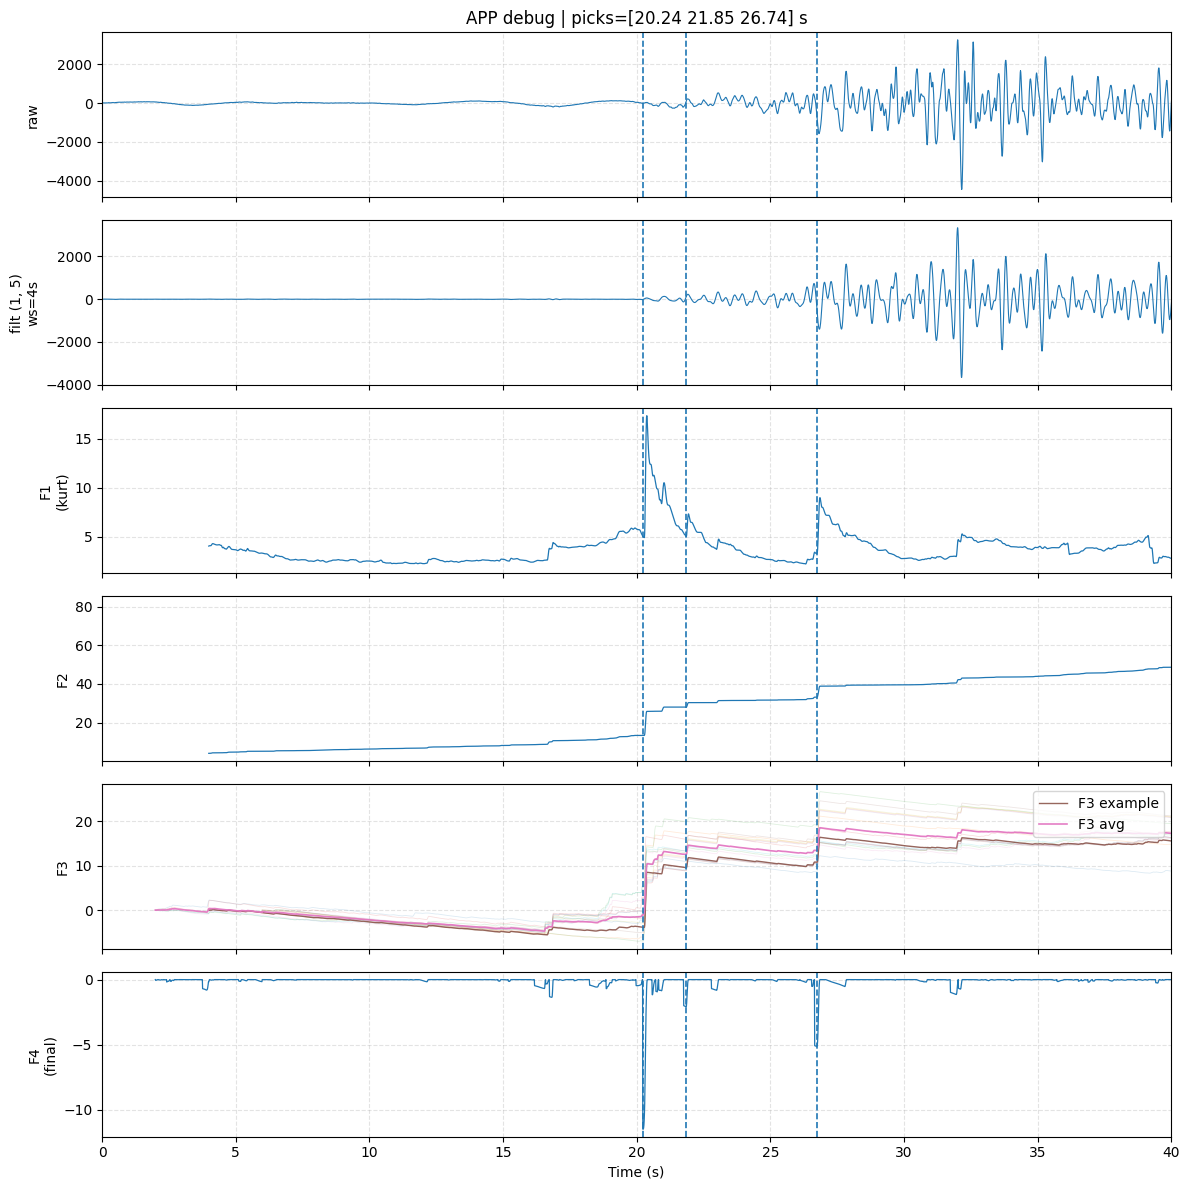

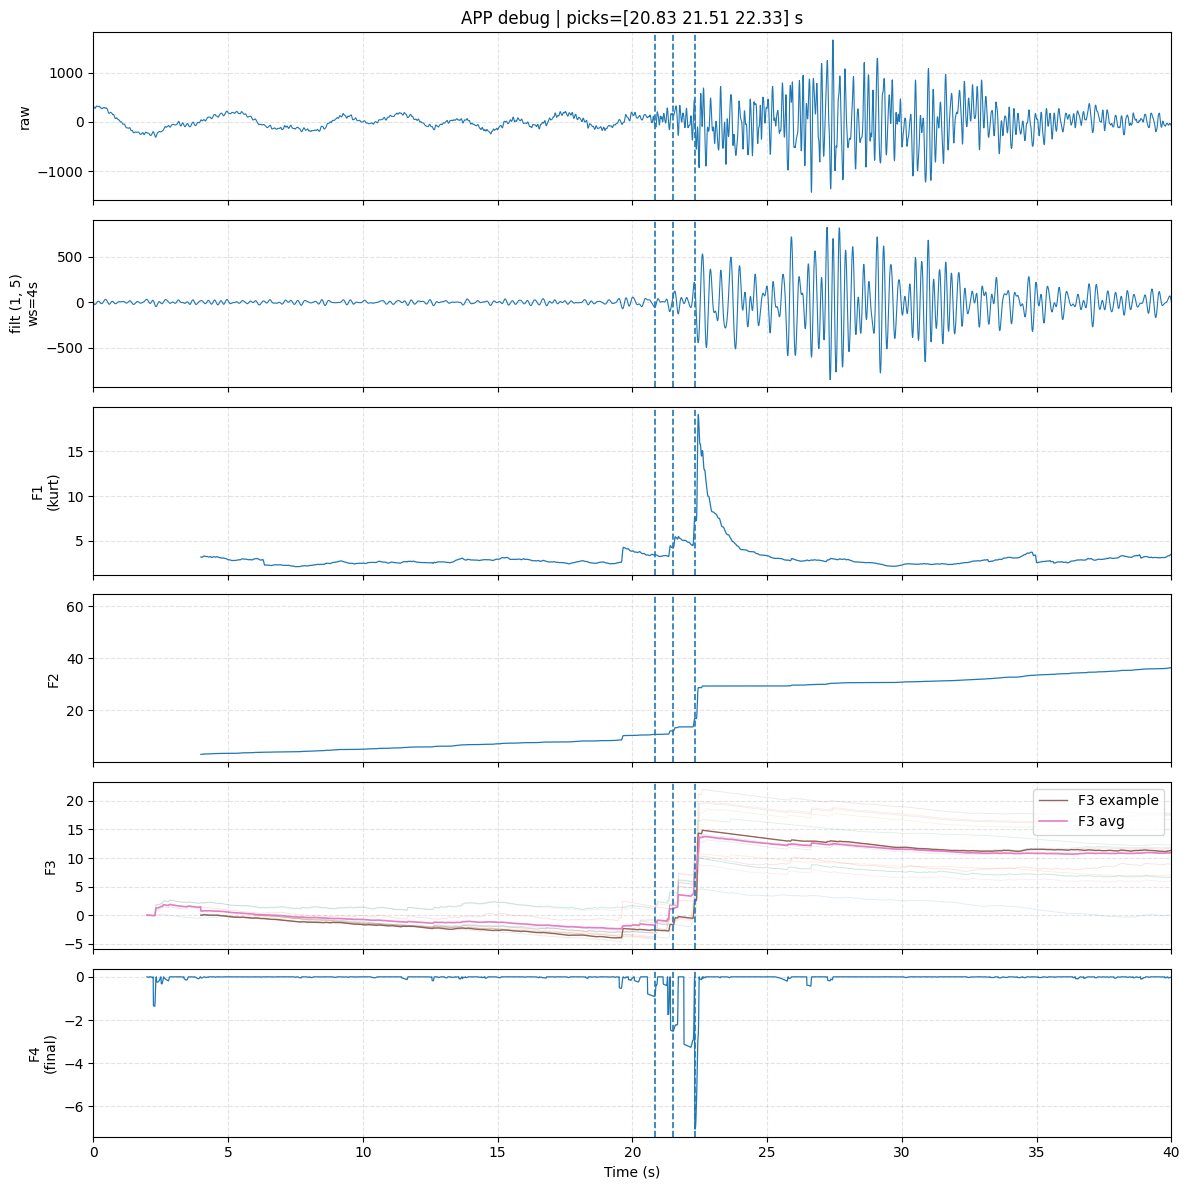

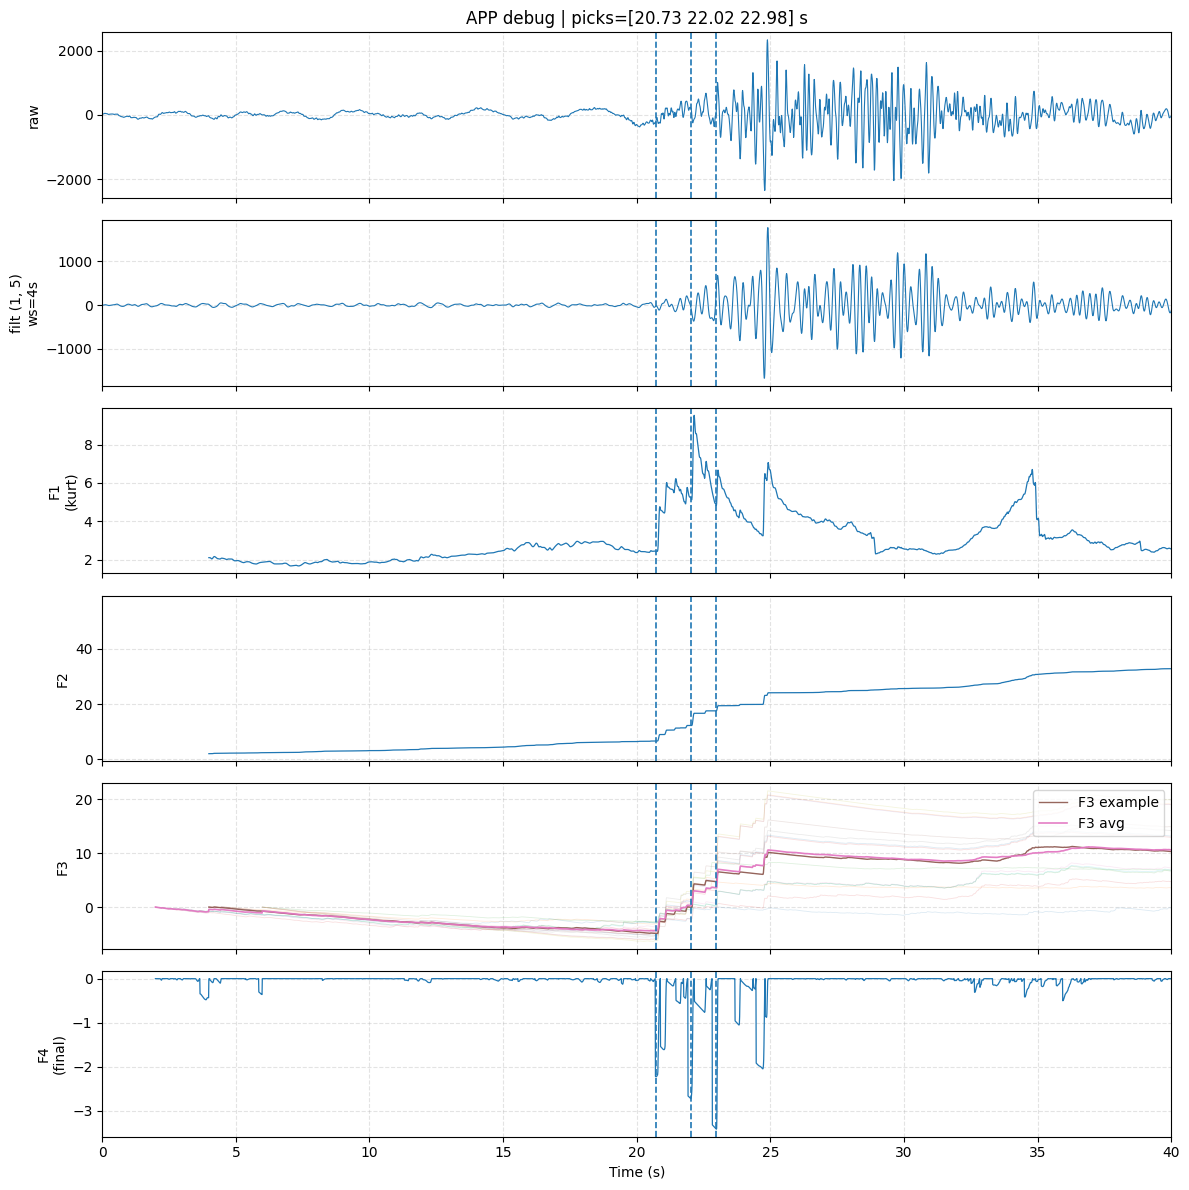

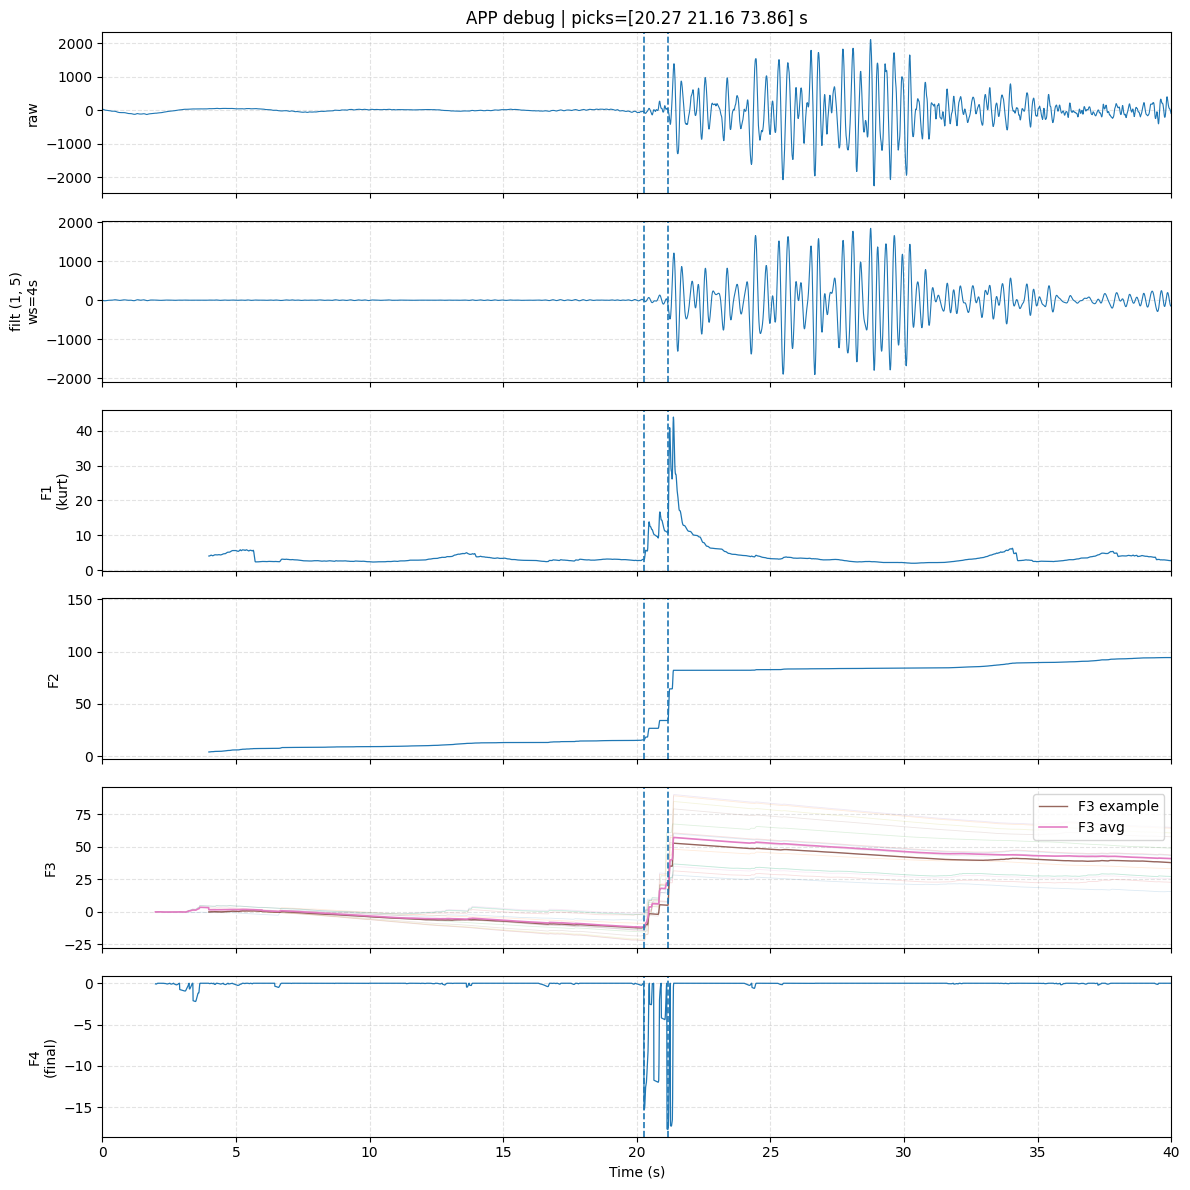

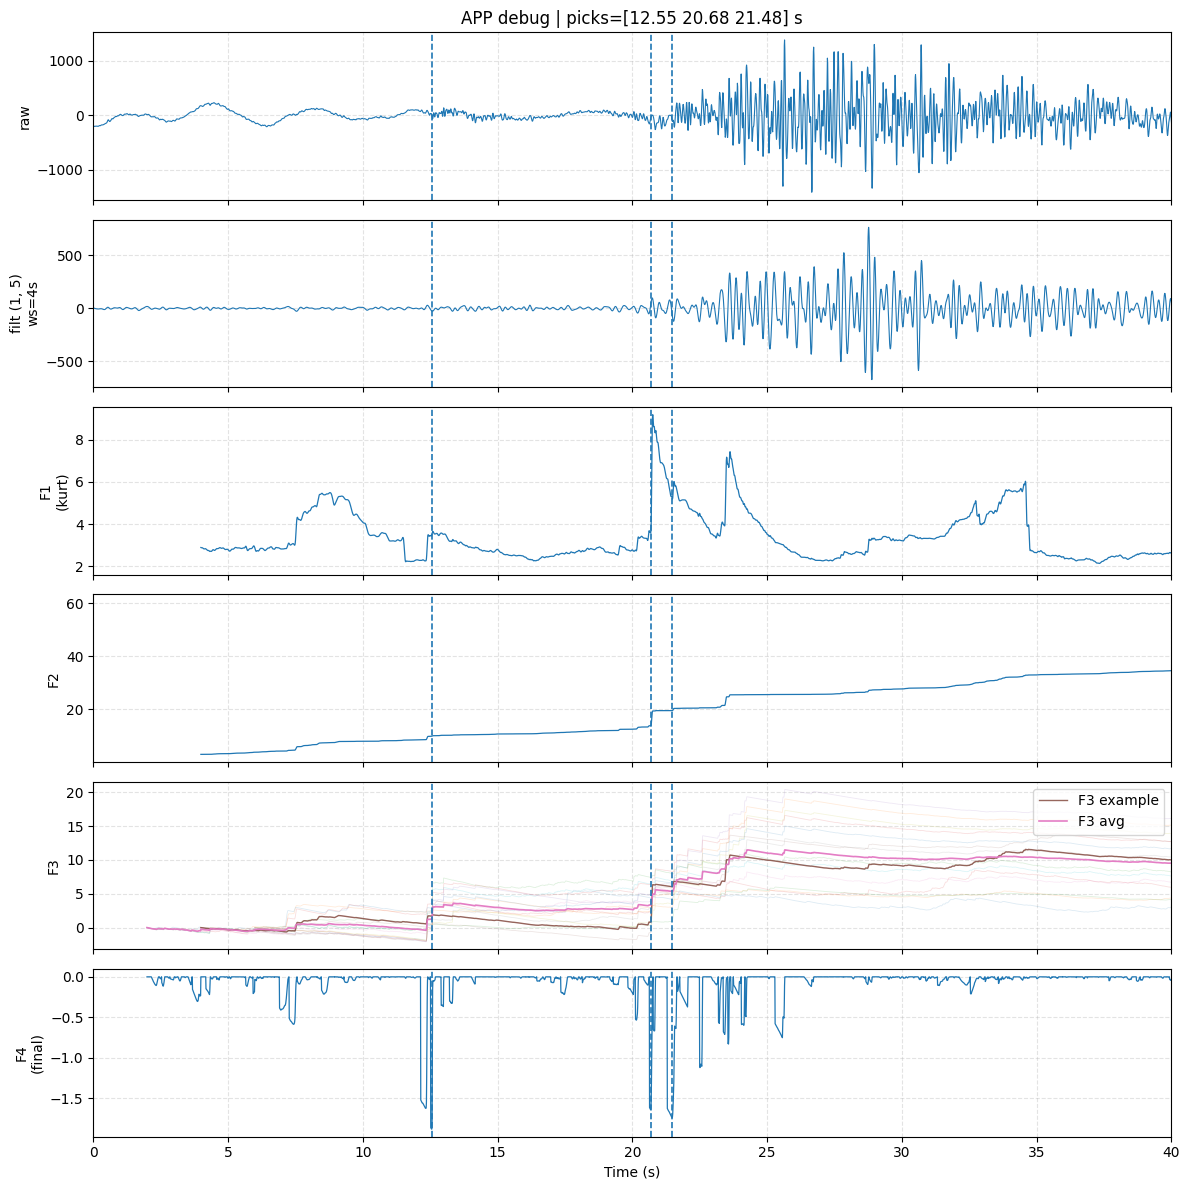

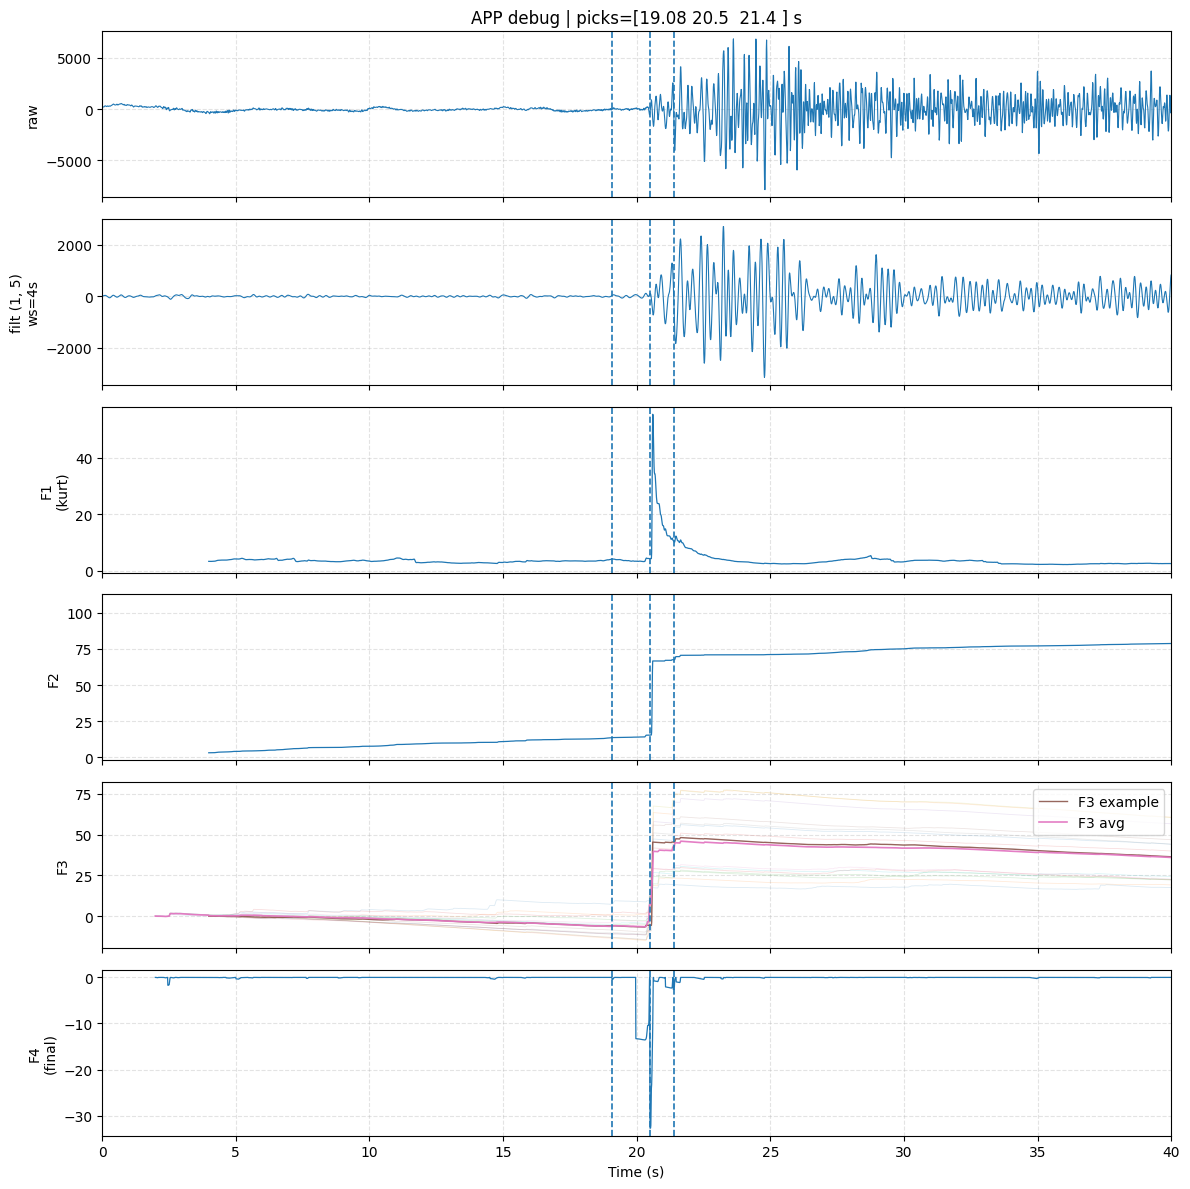

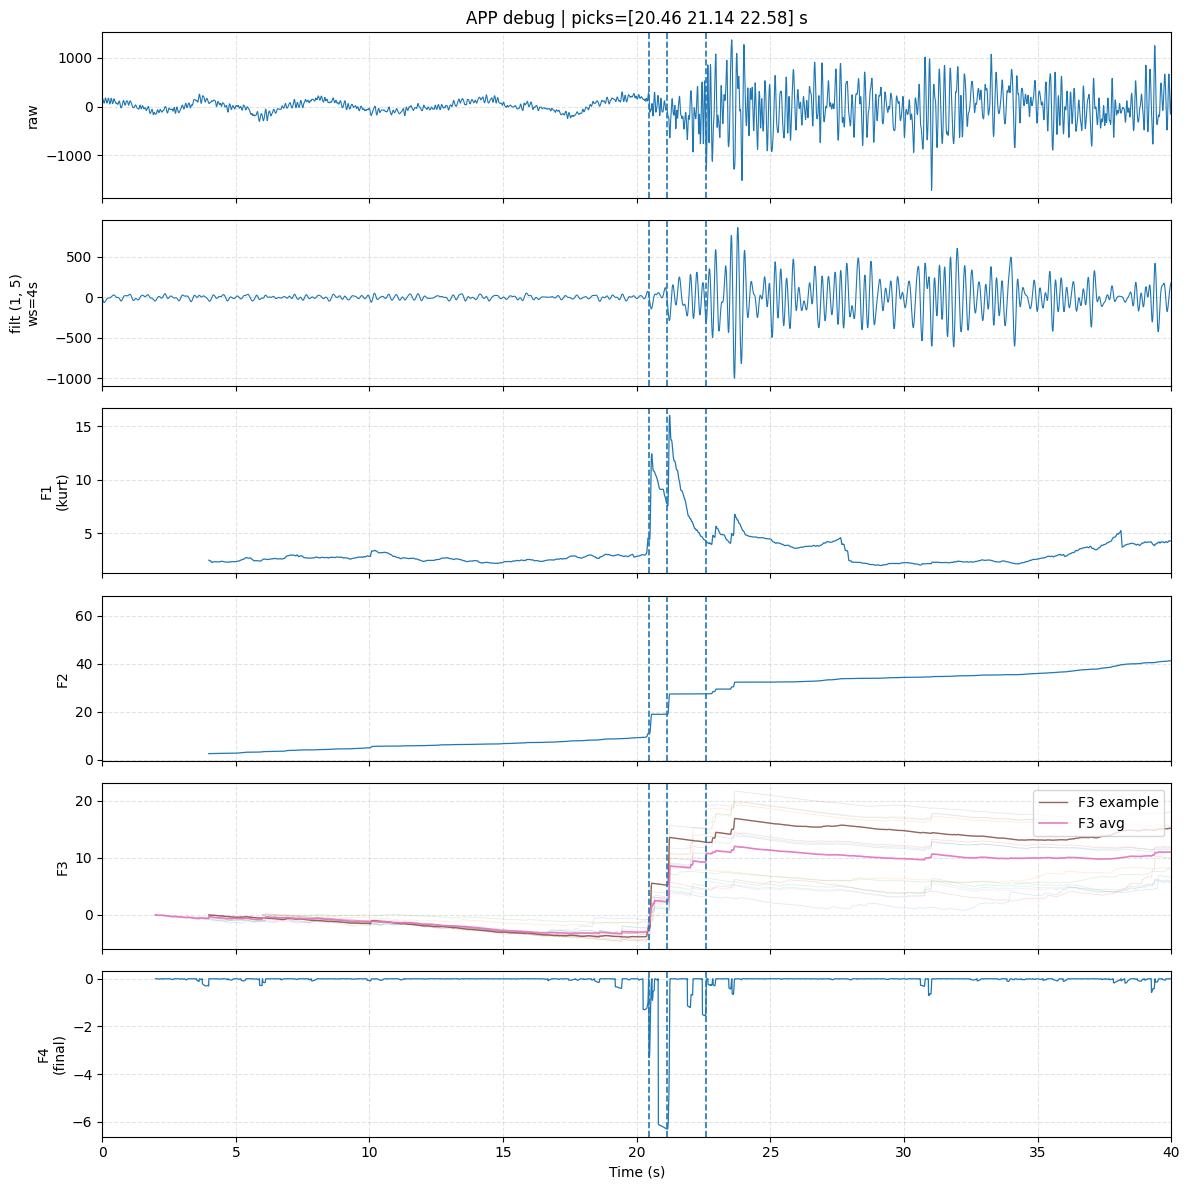

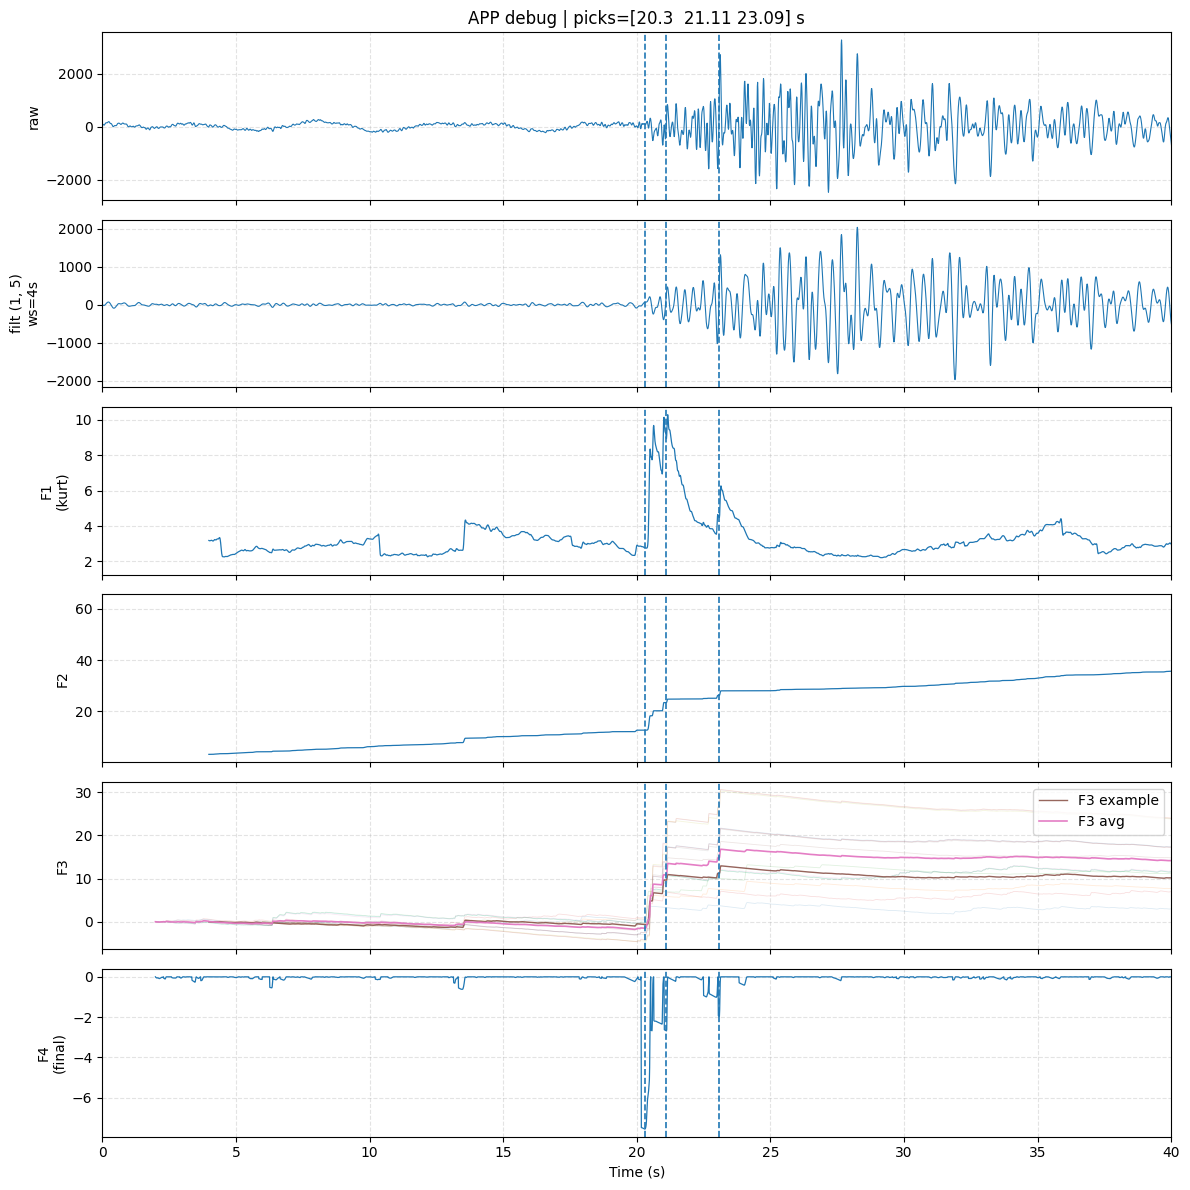

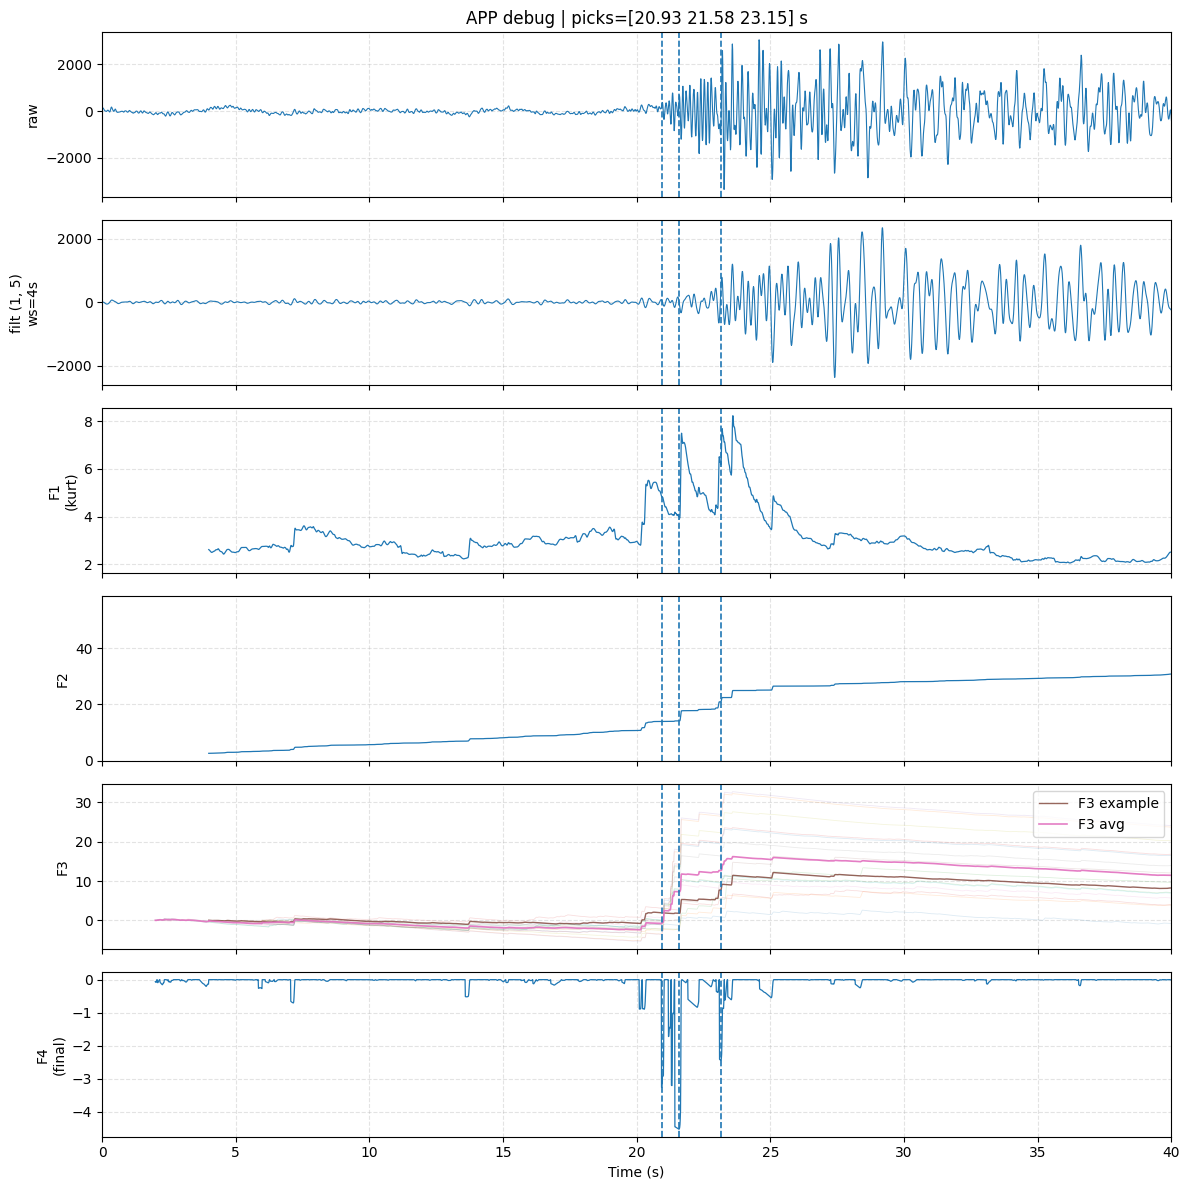

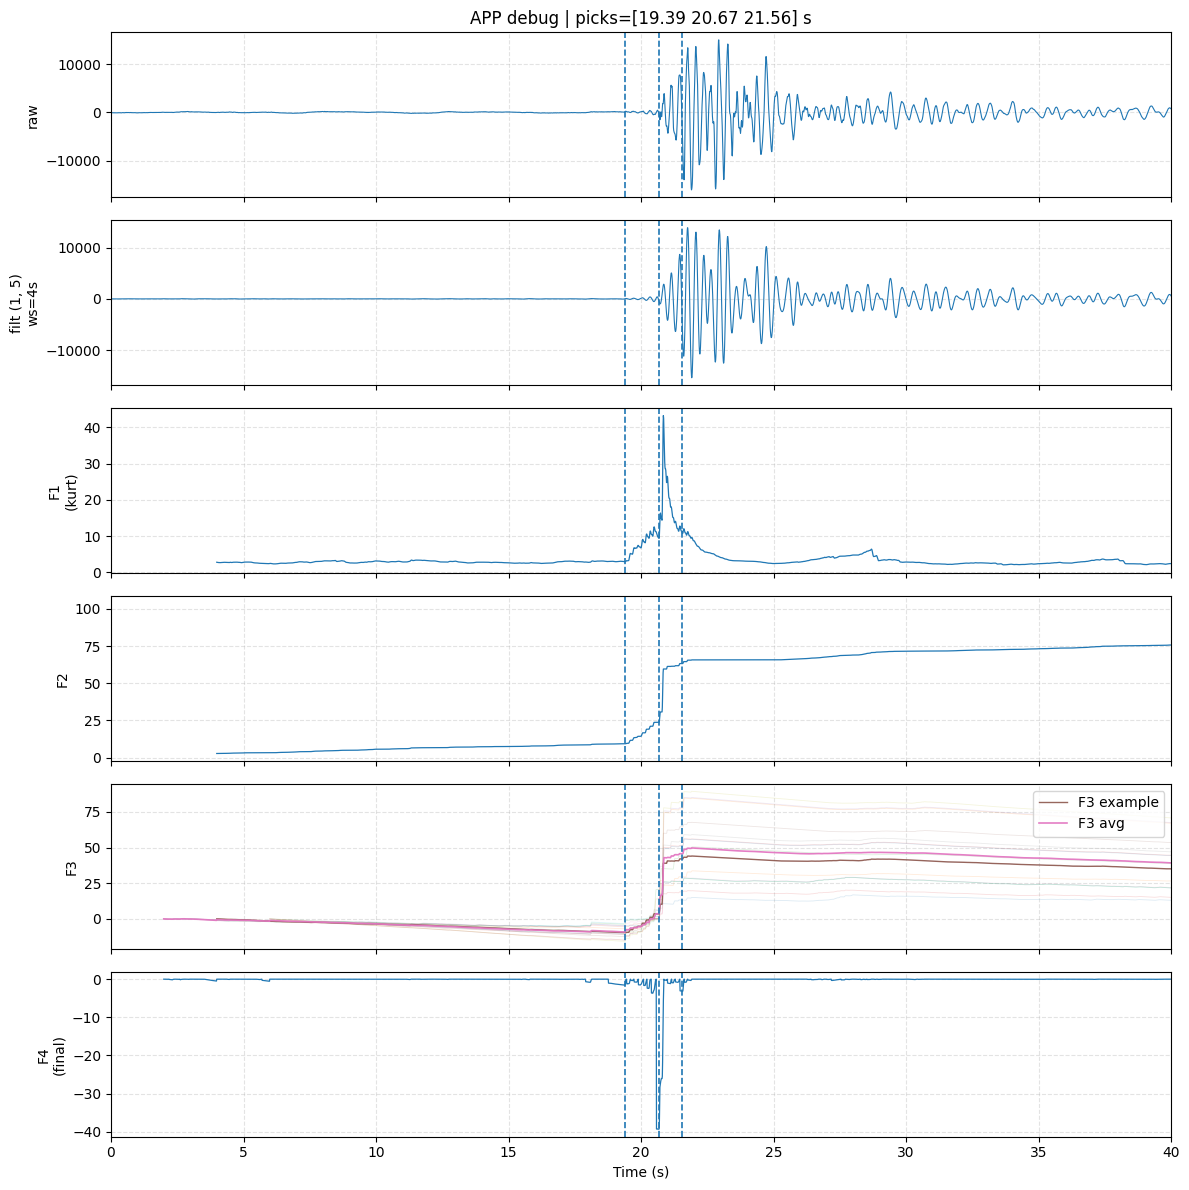

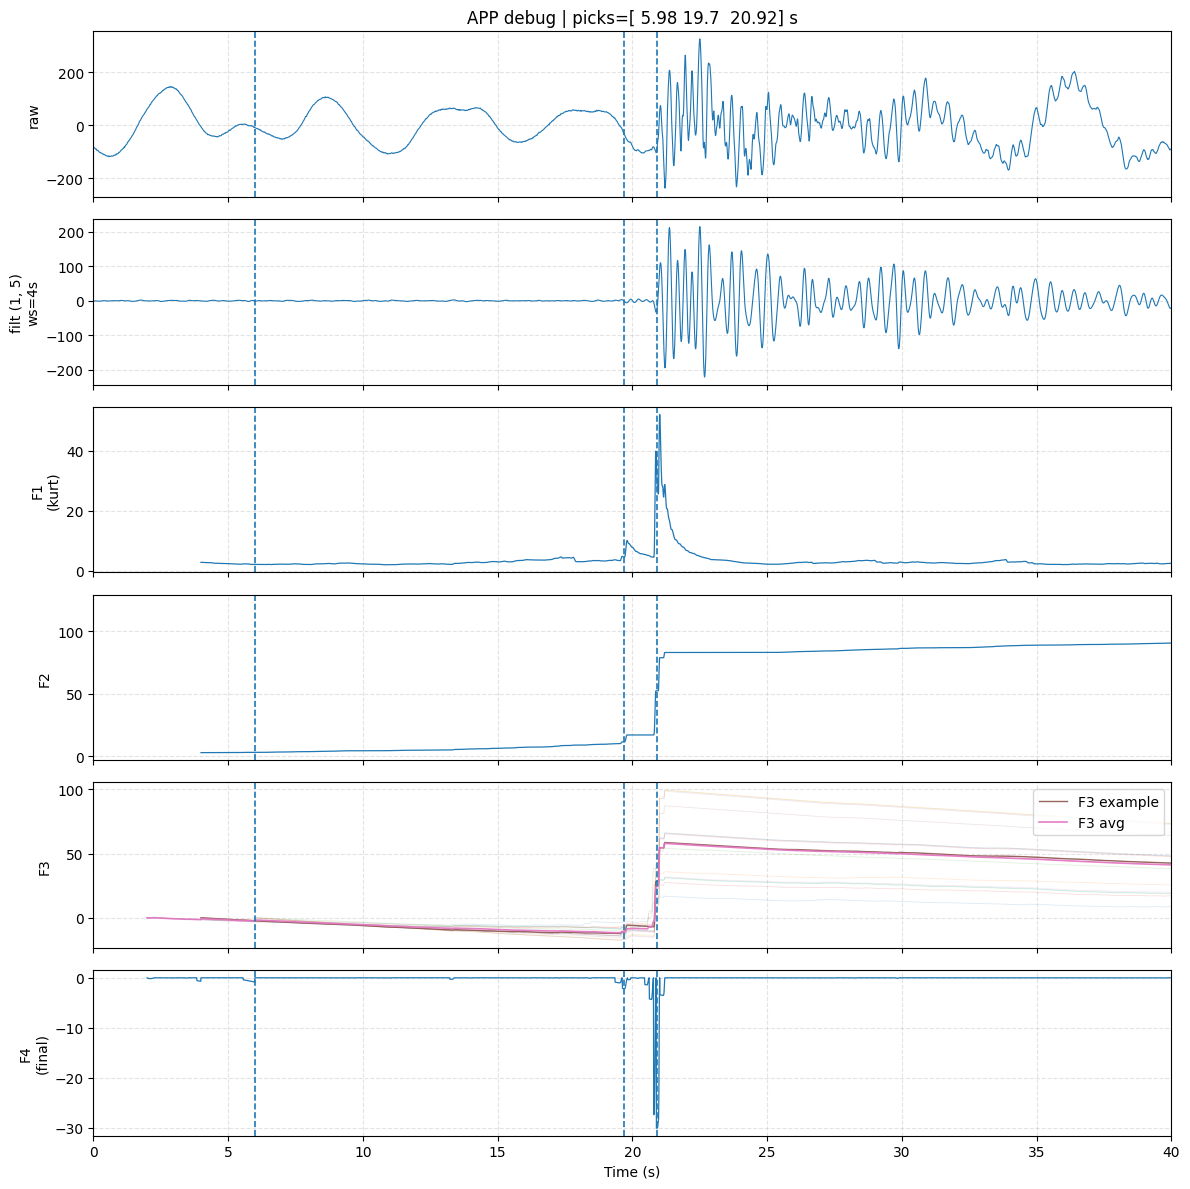

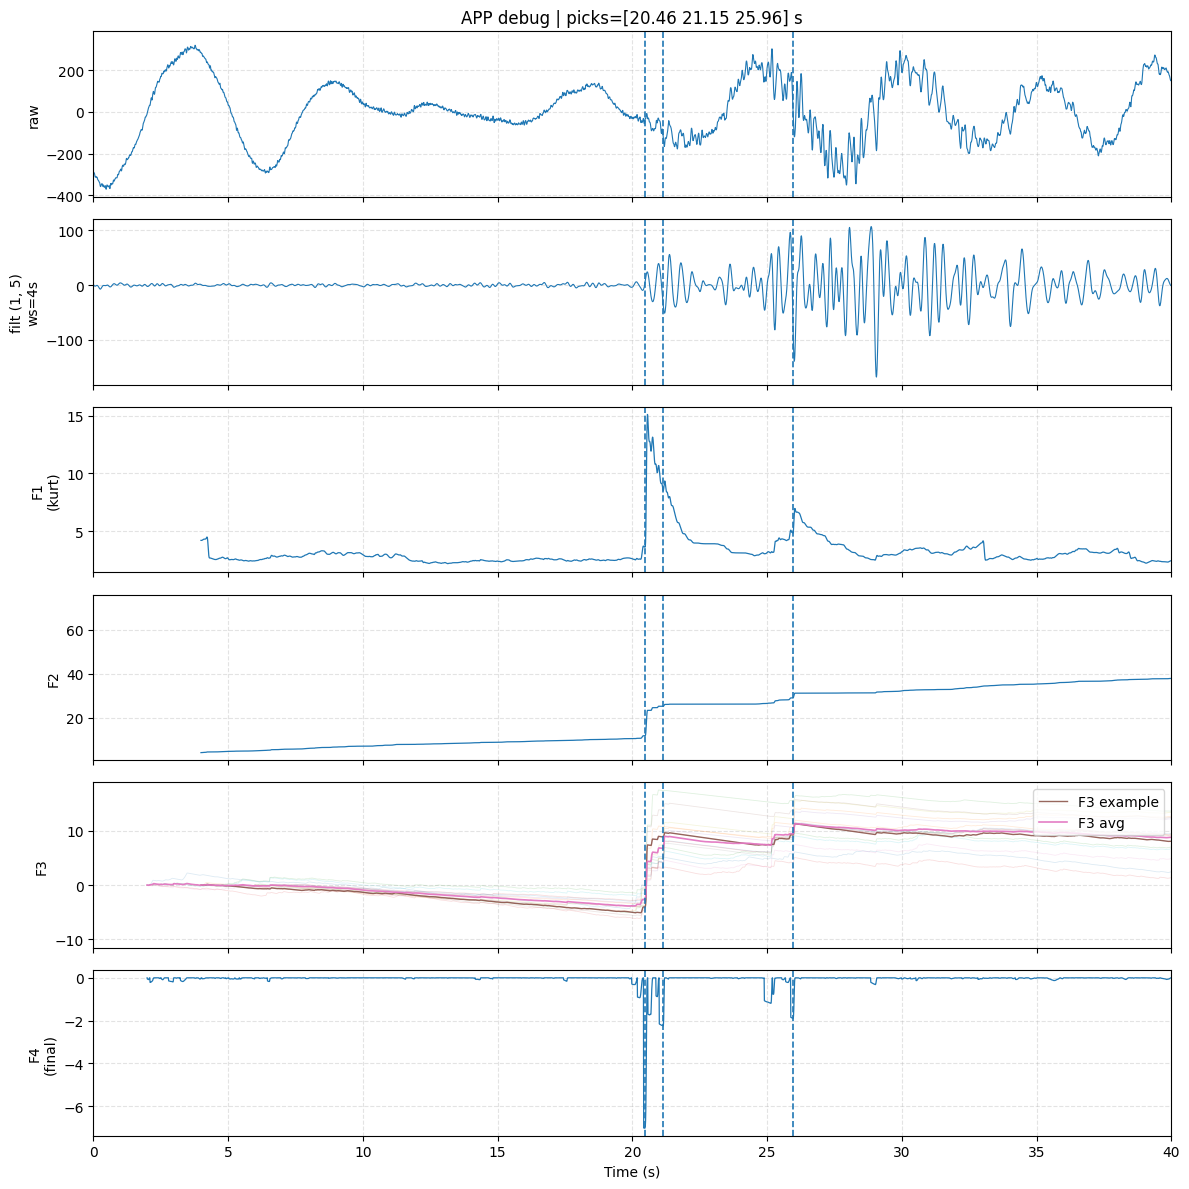

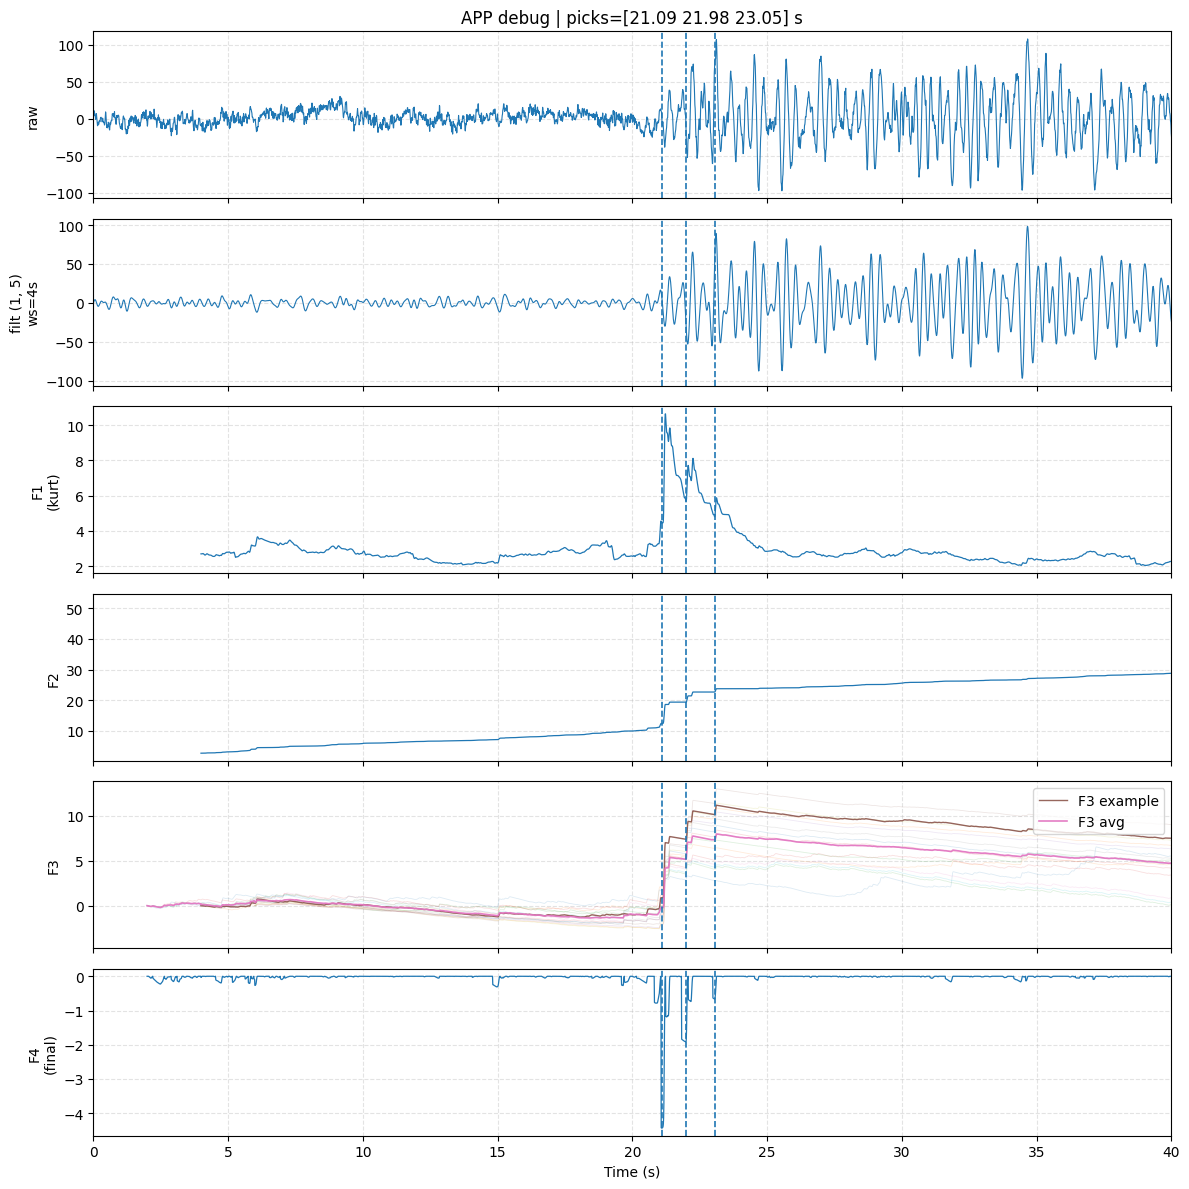

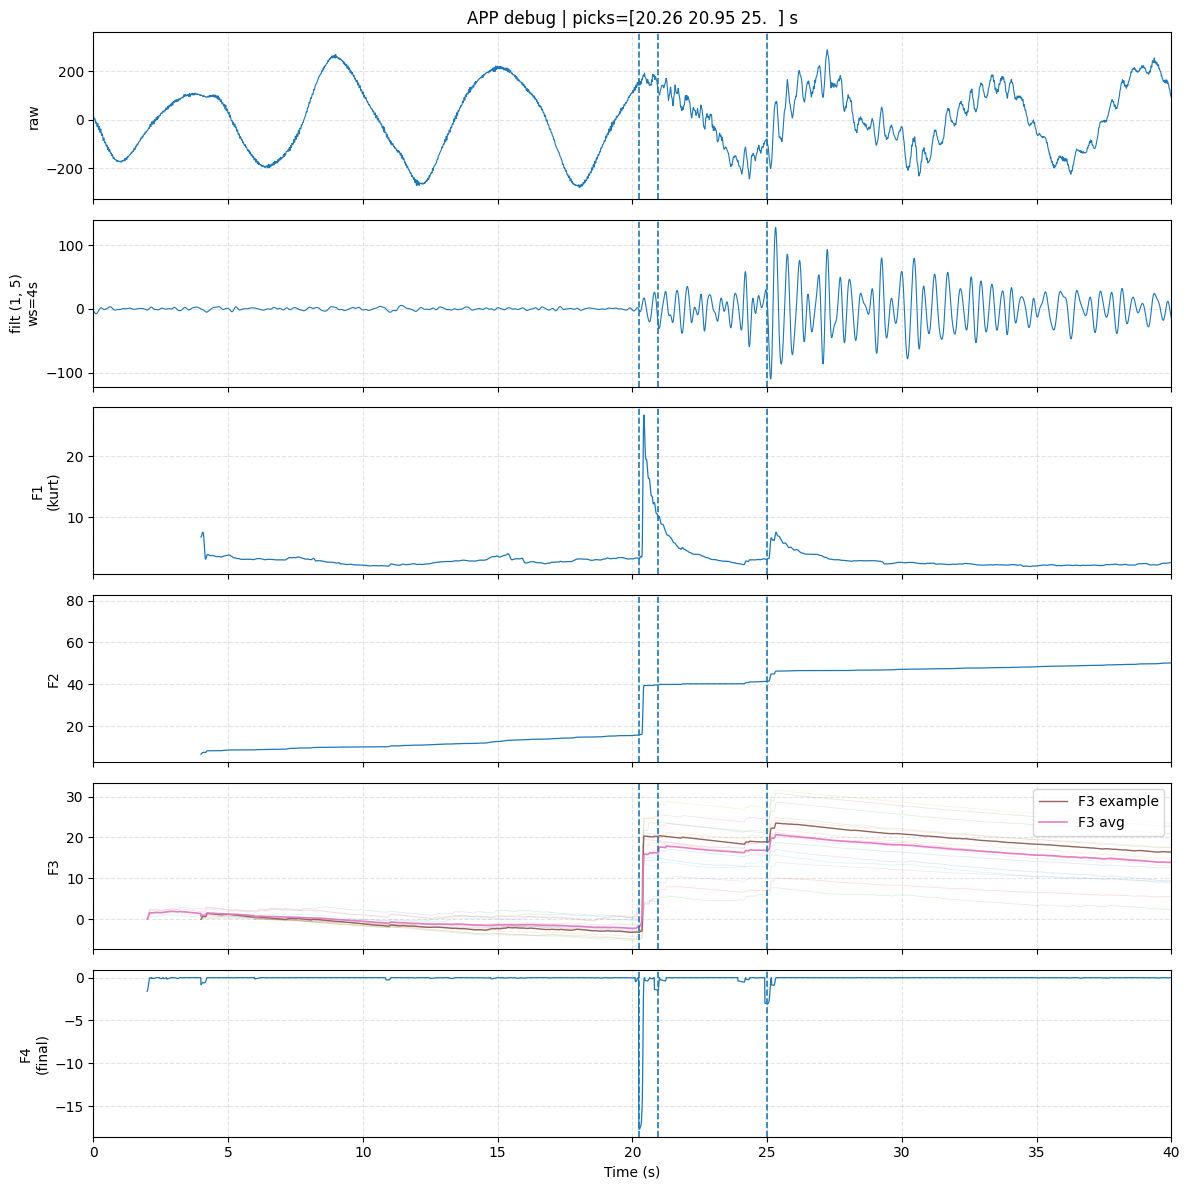

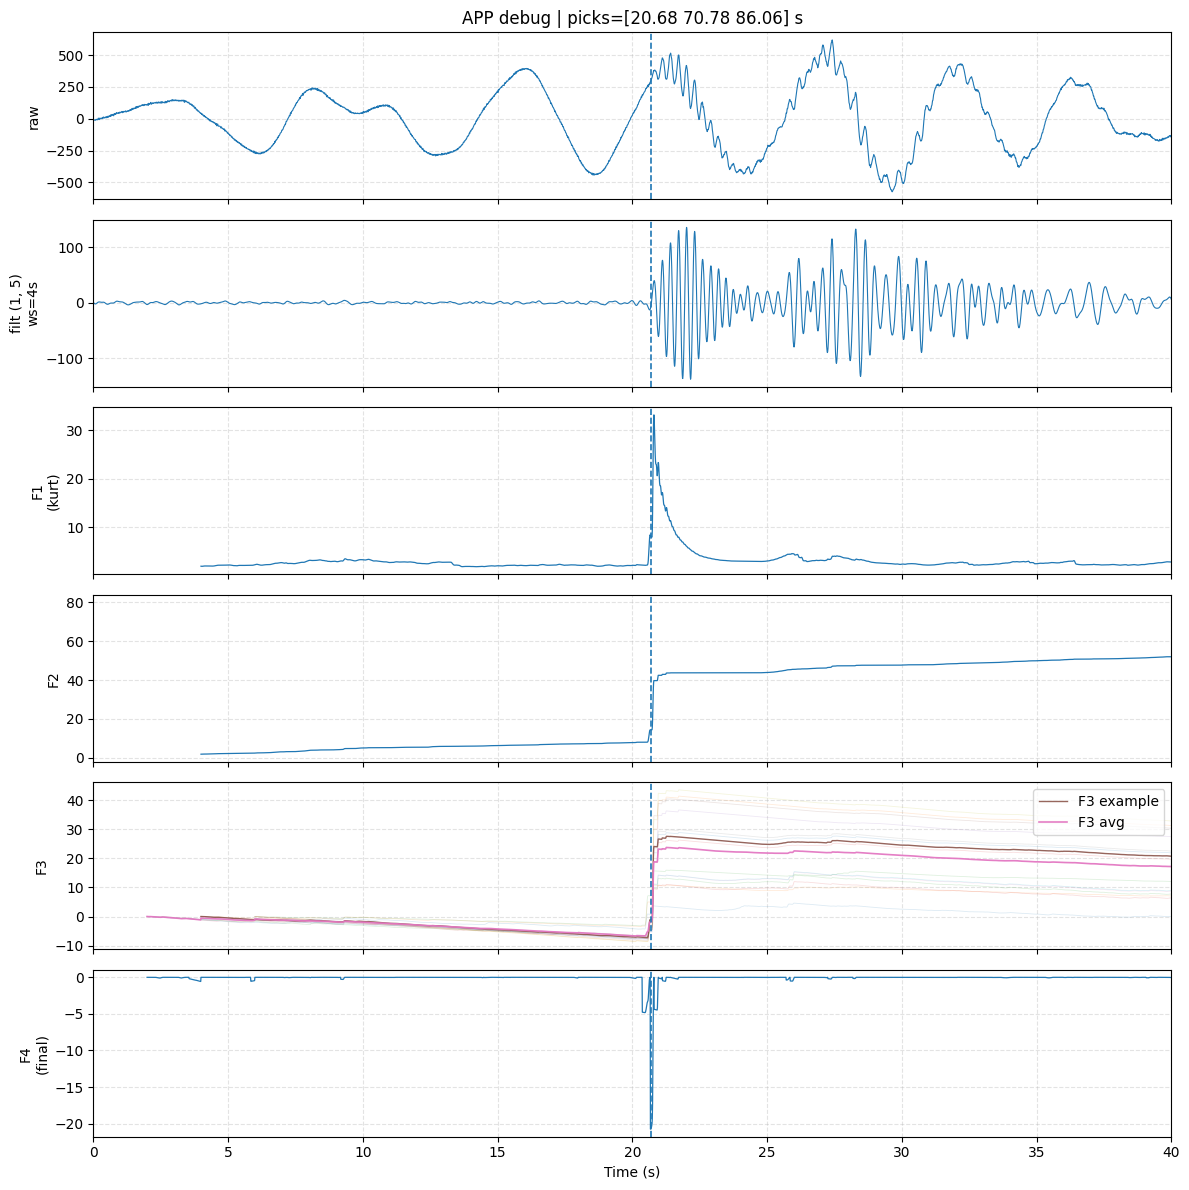

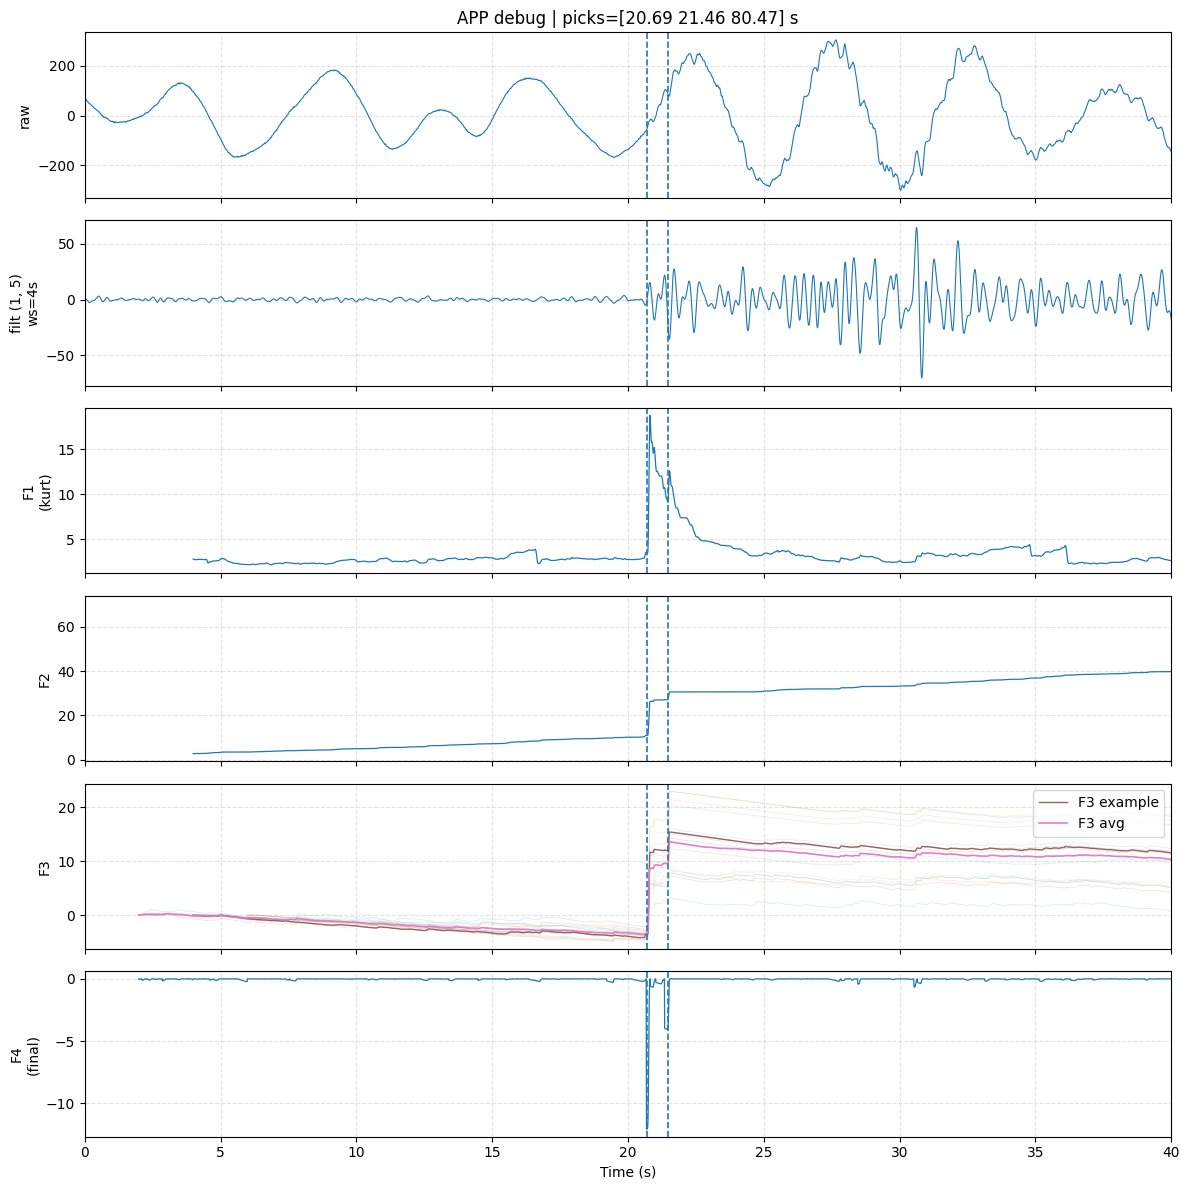

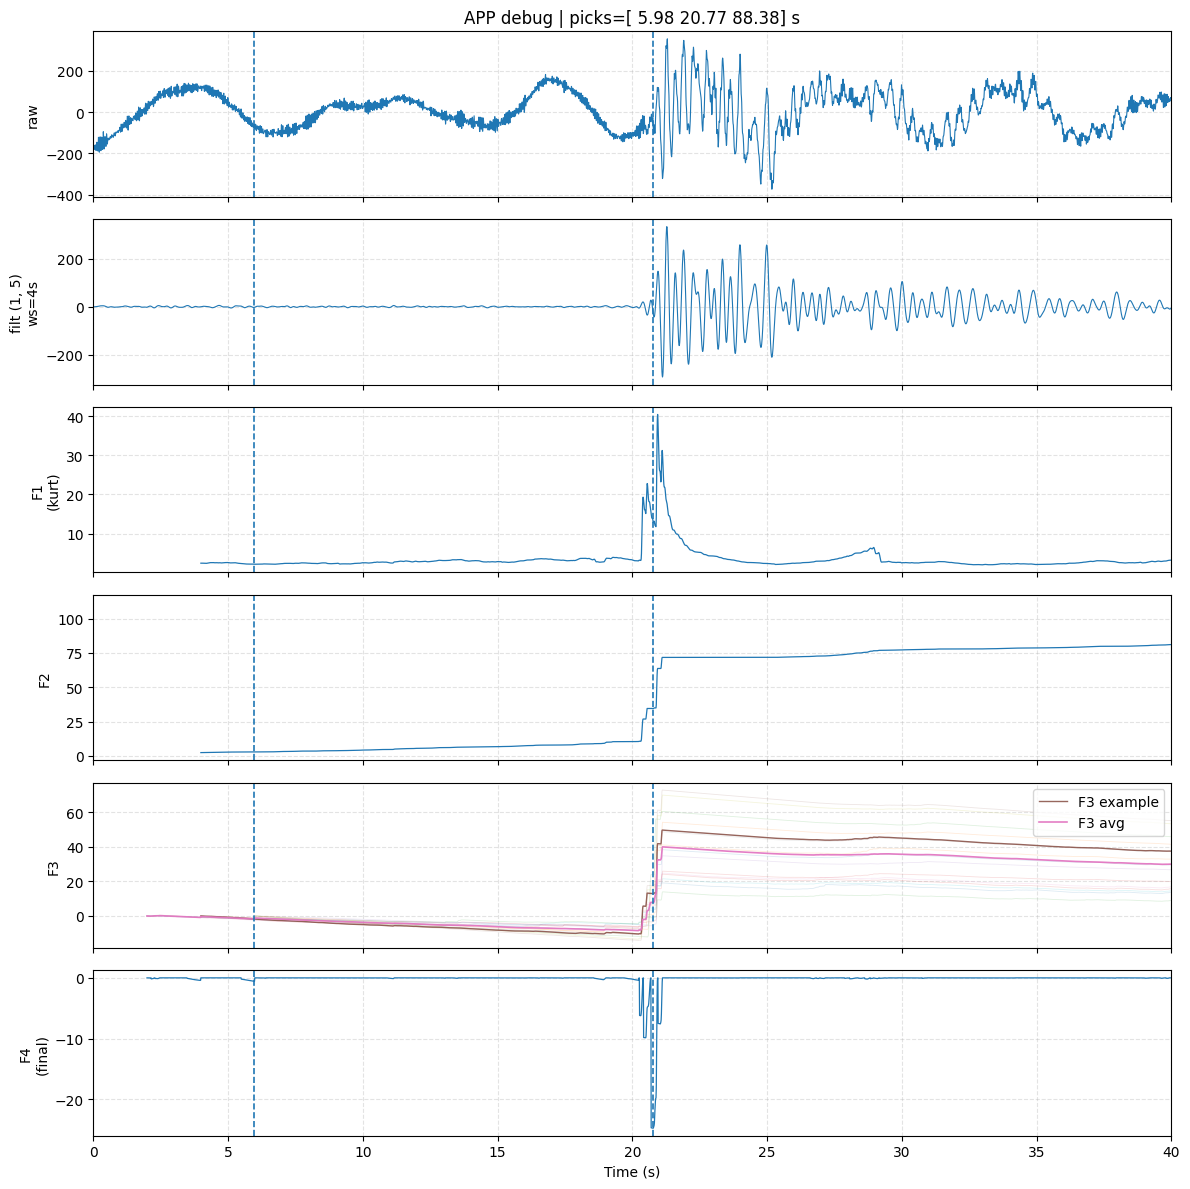

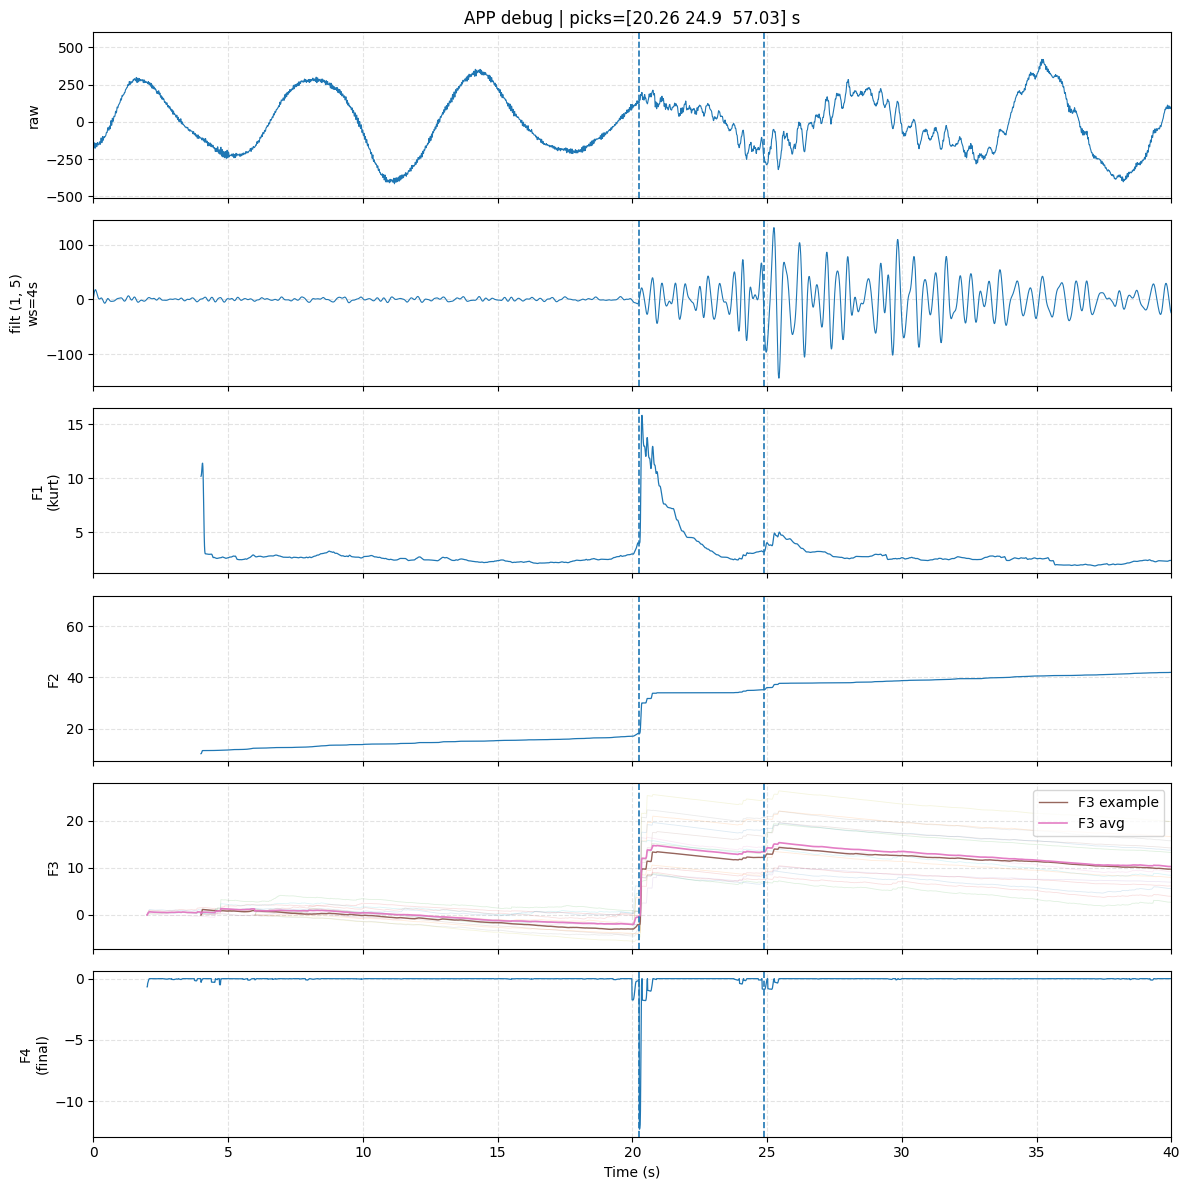

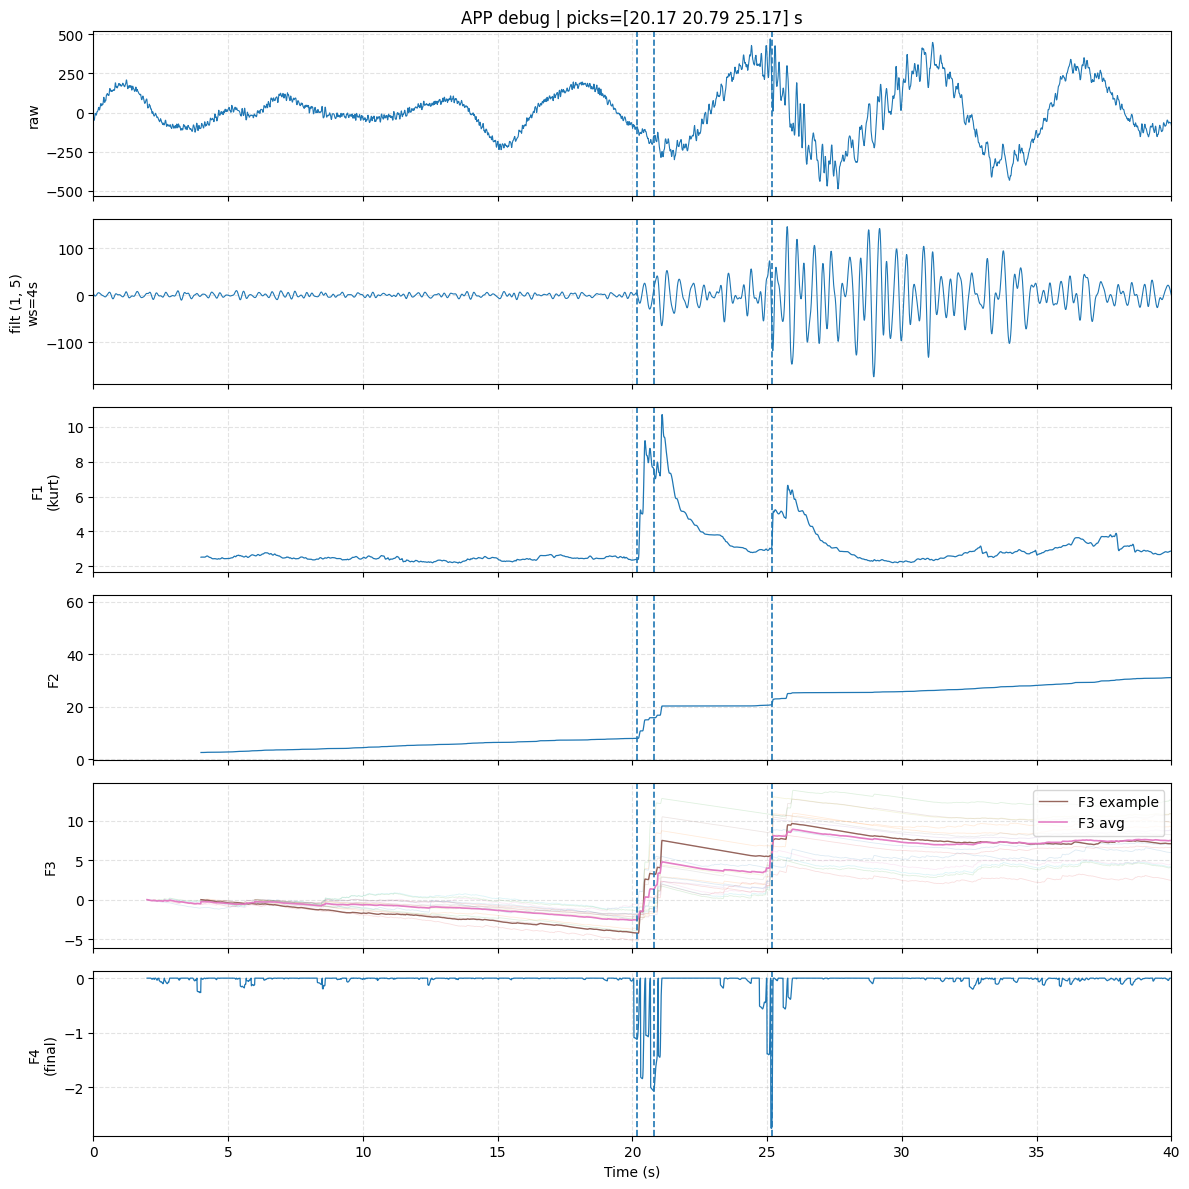

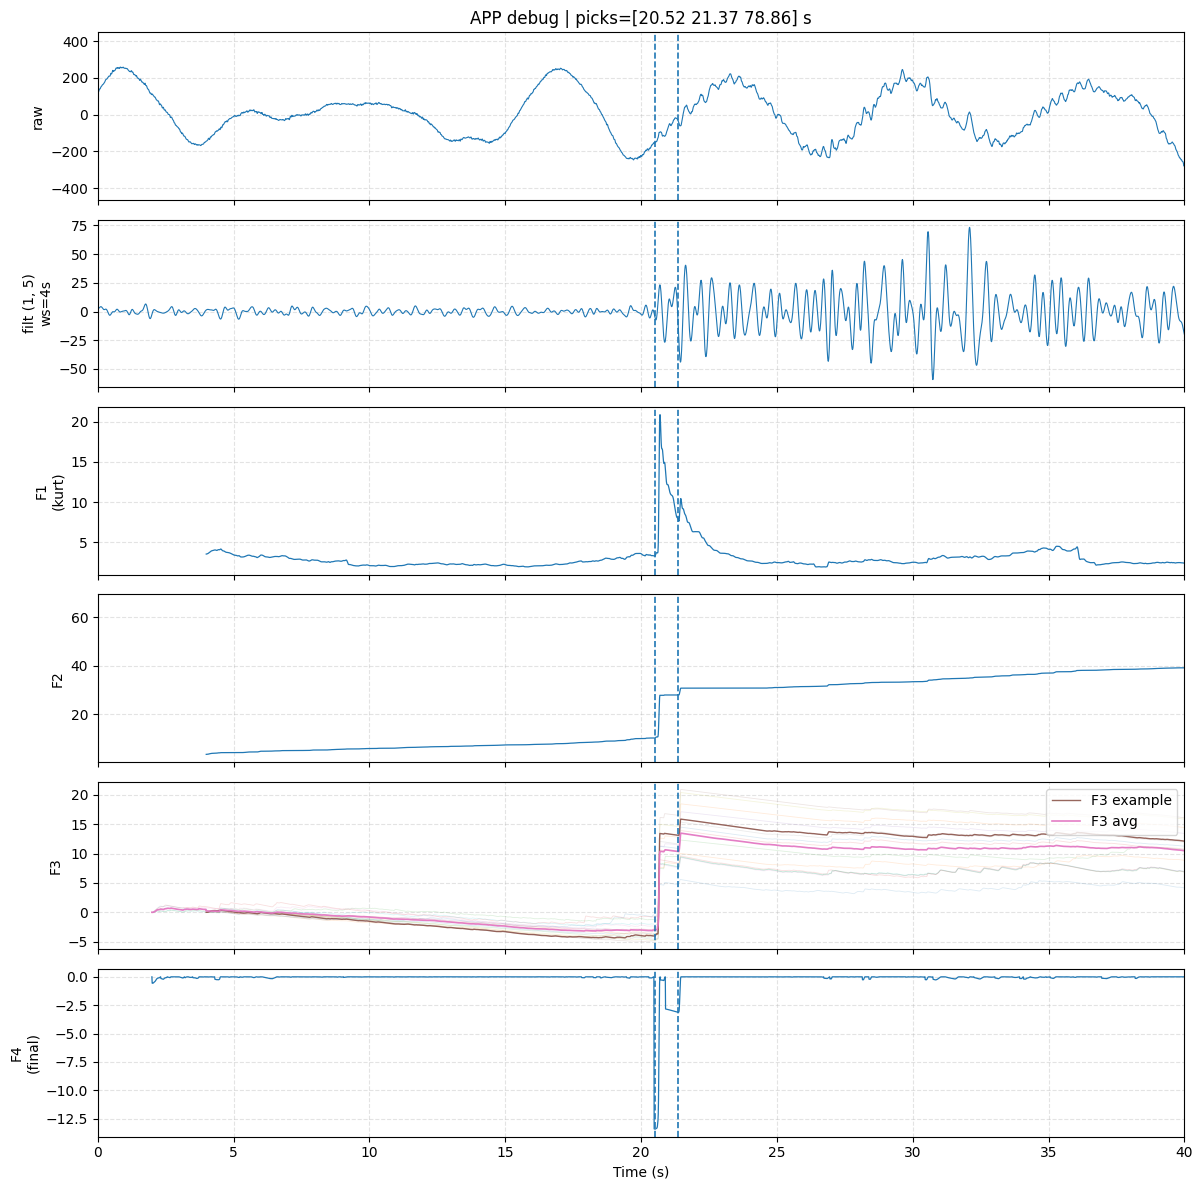

In [263]:
hdf5_path = file_paths['exotic']['hdf5']
f = h5py.File(hdf5_path)


for i in range(20): 
    z_data = f['/data/bucket1'][i, 2, 5000:15000]


    fs = 100.0

    picks_idx, picks_t, dbg = app_vertical_picker_with_debug(
        z_data,
        fs=fs,
        frequency_bands=[(1, 3), (1,5), (1,10), (1,15), (1,20)],
        ws_s=[2, 4, 6],
        smooth_windows_s=[2.0, 1.0, 0.5, 0.2],
        choose="strongest",
        max_picks= 3,
        debug_band=(1, 5),   # <-- which band you want to visualize for F1/F2/F3
        debug_ws_s=4,         # <-- which kurtosis window (s) you want to visualize
        lookahead_s = 1.0,           # Δ lookahead window for "peak follows dip"
        depth_weight = 0.2,          # small weight; Δ is main driver
    )

    plot_app_debug(dbg, fs, xlim_s=[0,40], title_prefix="APP debug", show_all_f3=True)


In [191]:
## ok download the seismic data from those five stations, compare the picks with other methods. 

In [192]:
import numpy as np
import matplotlib.pyplot as plt

def plot_waveform_with_picks(
    x,
    fs,
    picks_idx=None,
    picks_t=None,
    title="Waveform with picks",
    xlim_s=None,
):
    """
    Plot a single waveform and overlay picks.

    Provide either:
      - picks_idx (sample indices), or
      - picks_t (seconds)
    """
    x = np.asarray(x, dtype=float)
    t = np.arange(len(x)) / float(fs)

    if picks_t is None and picks_idx is not None:
        picks_t = np.asarray(picks_idx) / float(fs)
    if picks_t is None:
        picks_t = np.array([])

    plt.figure(figsize=(12, 4))
    plt.plot(t, x, lw=0.8)
    for pt in np.asarray(picks_t):
        plt.axvline(pt, linestyle="--", linewidth=1.2)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.4)
    if xlim_s is not None:
        plt.xlim(*xlim_s)
    plt.tight_layout()
    plt.show()


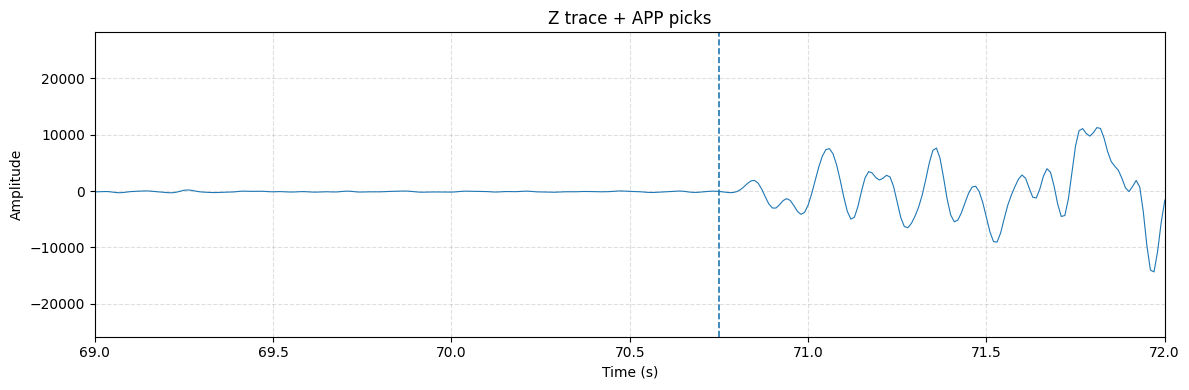

In [193]:
plot_waveform_with_picks(z_data, fs, picks_idx=picks_idx, title="Z trace + APP picks", xlim_s = [69, 72])


## Understanding what could be the correct value of Lookahead window. 

For that we will iterate through bunch of lookahead windows and compare the errors and distribution for each window

In [ ]:
hdf5_path = file_paths['exotic']['hdf5']
f = h5py.File(hdf5_path)
z_data = f['/data/bucket1'][3990, 2, :]

In [207]:
int(cat_su['trace_name'].values[0].split('$')[1].split(',')[0])

0

In [208]:
buckets = np.array([val.split('$')[0] for val in cat_su['trace_name'].values])
trace_indices = np.array([int(val.split('$')[1].split(',')[0]) for val in cat_su['trace_name'].values])

In [235]:
picks_overall = []
for i, trace_info in tqdm(enumerate(zip(buckets, trace_indices))):
    bucket = trace_info[0]
    trace_idx = trace_info[1]
    z_data = f[f'/data/{bucket}'][trace_idx, 2, :]
    
    picks_idx, picks_t, dbg = app_vertical_picker_with_debug(
    z_data,
    fs=fs,
    frequency_bands=[(1, 3), (1,5), (1,10), (1,15), (1,20)],
    ws_s=[2, 4, 6],
    smooth_windows_s=[2.0, 1.0, 0.5, 0.2],
    choose="strongest",
    max_picks= 3,
    ignore_first_s = 20.0,
    debug_band=(1, 5),   # <-- which band you want to visualize for F1/F2/F3
    debug_ws_s=4,         # <-- which kurtosis window (s) you want to visualize
    lookahead_s = 1.0,           # Δ lookahead window for "peak follows dip"
    depth_weight = 0.1,          # small weight; Δ is main driver
)
    
    picks_overall.append(picks_idx)

    
    if i > 500:
        break
    

0it [00:00, ?it/s]/tmp/ipykernel_3783873/1492965939.py:477: RuntimeWarning: Mean of empty slice
  F3_avg = np.nanmean(F3_stack, axis=0)
501it [00:23, 21.60it/s]


In [237]:
picks_overall

[array([ 3279,  7024, 16490]),
 array([4407, 7151, 7233]),
 array([7071, 7202, 7298]),
 array([ 7027,  7116, 17986]),
 array([ 6256,  7148, 16036]),
 array([ 7050,  7140, 17987]),
 array([2067, 7046, 7114]),
 array([7030, 7111, 7309]),
 array([7093, 7158, 7315]),
 array([6939, 7067, 7156]),
 array([ 6970,  7092, 17977]),
 array([ 7046,  7115, 17980]),
 array([4229, 7109, 7198]),
 array([ 7026,  7499, 17978]),
 array([ 7068, 16012, 17978]),
 array([ 7069,  7146, 17978]),
 array([ 2337,  7077, 17980]),
 array([ 7026,  7490, 17987]),
 array([7017, 7079, 7517]),
 array([5161, 7052, 7137]),
 array([ 8048, 15479, 16051]),
 array([ 6973,  7086, 12656]),
 array([6901, 6988, 7054]),
 array([ 7071, 14901, 17977]),
 array([ 7025,  7415, 12581]),
 array([2339, 7035, 7517]),
 array([ 7059,  7123, 10907]),
 array([5060, 7048, 7967]),
 array([ 7058,  7257, 11223]),
 array([7096, 7166, 7286]),
 array([7085, 7251, 7321]),
 array([ 6902,  7054, 17980]),
 array([ 7018,  7508, 17978]),
 array([ 7030,  750

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from scipy.signal import spectrogram

# ----------------------------
# Fetch Z component for a station (auto-detect net + best Z channel)
# ----------------------------
def fetch_vertical_trace(client, station, start, end, preferred_prefixes=("HH", "BH", "EH")):
    """
    Tries to find a *HZ channel for the given station and time window, preferring
    HHZ > BHZ > EHZ by default. Returns (tr, net, sta, chan) or None.
    """
    inv = client.get_stations(
        station=station,
        channel="*HZ",
        starttime=start,
        endtime=end,
        level="channel"
    )

    # collect (net, sta, loc, chan, sr)
    candidates = []
    for net in inv:
        for sta in net:
            for ch in sta.channels:
                chan = ch.code  # e.g. HHZ
                loc = ch.location_code or ""
                sr = getattr(ch, "sample_rate", None)
                candidates.append((net.code, sta.code, loc, chan, sr))

    if not candidates:
        return None

    # rank by preferred channel prefix order, then by sample rate (desc)
    def score(item):
        net, sta, loc, chan, sr = item
        pref_rank = 999
        for i, p in enumerate(preferred_prefixes):
            if chan.startswith(p) and chan.endswith("Z"):
                pref_rank = i
                break
        sr_val = sr if sr is not None else 0.0
        return (pref_rank, -sr_val)

    candidates.sort(key=score)
    net, sta, loc, chan, sr = candidates[0]

    st = client.get_waveforms(net, sta, loc or "*", chan, start, end)
    st.merge(method=1, fill_value="interpolate")
    tr = st[0]

    # basic cleanup
    tr.detrend("linear")
    tr.detrend("demean")
    tr.taper(max_percentage=0.02)

    return tr, net, sta, chan


def fetch_vertical_trace(client, station, start, end, preferred_prefixes=("HH", "BH", "EH")):
    """
    Finds a *HZ channel for the given station + time window, preferring HHZ > BHZ > EHZ,
    downloads it, and applies preprocessing:
      detrend linear
      taper 0.01
      bandpass 1–20 Hz
    Returns (tr, net, sta, chan) or None.
    """
    inv = client.get_stations(
        station=station,
        channel="*HZ",
        starttime=start,
        endtime=end,
        level="channel"
    )

    candidates = []
    for net in inv:
        for sta in net:
            for ch in sta.channels:
                chan = ch.code
                loc = ch.location_code or ""
                sr = getattr(ch, "sample_rate", None)
                candidates.append((net.code, sta.code, loc, chan, sr))

    if not candidates:
        return None

    def score(item):
        net, sta, loc, chan, sr = item
        pref_rank = 999
        for i, p in enumerate(preferred_prefixes):
            if chan.startswith(p) and chan.endswith("Z"):
                pref_rank = i
                break
        sr_val = sr if sr is not None else 0.0
        return (pref_rank, -sr_val)

    candidates.sort(key=score)
    net, sta, loc, chan, sr = candidates[0]

    st = client.get_waveforms(net, sta, loc or "*", chan, start, end)

    # ── waveform preprocessing ─────────────────────────────────
    st.detrend("linear")
    st.taper(0.01)
    st.filter("bandpass", freqmin=1, freqmax=20)

    # merge after preprocessing (keep it continuous)
    st.merge(method=1, fill_value="interpolate")
    tr = st[0]

    return tr, net, sta, chan


def fetch_vertical_traces(client, station, start, end, preferred_prefixes=("HH", "BH", "EH")):
    """
    Returns TWO traces:
      - tr_raw: merged, continuous, NOT filtered (for kurtosis picker)
      - tr_plot: detrend+0.01 taper + 1-20 Hz bandpass (for waveform+spectrogram plots)

    Returns (tr_raw, tr_plot, net, sta, chan) or None.
    """
    inv = client.get_stations(
        station=station,
        channel="*HZ",
        starttime=start,
        endtime=end,
        level="channel"
    )

    candidates = []
    for net in inv:
        for sta in net:
            for ch in sta.channels:
                chan = ch.code
                loc = ch.location_code or ""
                sr = getattr(ch, "sample_rate", None)
                candidates.append((net.code, sta.code, loc, chan, sr))

    if not candidates:
        return None

    def score(item):
        net, sta, loc, chan, sr = item
        pref_rank = 999
        for i, p in enumerate(preferred_prefixes):
            if chan.startswith(p) and chan.endswith("Z"):
                pref_rank = i
                break
        sr_val = sr if sr is not None else 0.0
        return (pref_rank, -sr_val)

    candidates.sort(key=score)
    net, sta, loc, chan, sr = candidates[0]

    st = client.get_waveforms(net, sta, loc or "*", chan, start, end)

    # ---- RAW (for picker): merge only, do NOT bandpass here
    st_raw = st.copy()
    st_raw.merge(method=1, fill_value="interpolate")
    tr_raw = st_raw[0]
    tr_raw.detrend("demean")     # mild + safe
    tr_raw.detrend("linear")     # optional, helps baseline

    # ---- PLOT (for display): your preprocessing
    st_plot = st.copy()
    st_plot.merge(method=1, fill_value="interpolate")
    st_plot.detrend("linear")
    st_plot.taper(0.01)
    st_plot.filter("bandpass", freqmin=1, freqmax=20)
    tr_plot = st_plot[0]

    return tr_raw, tr_plot, net, sta, chan



# ----------------------------
# Resample trace to fs_target (100 Hz) and return numpy array + dt
# ----------------------------
def trace_to_array_resampled(tr, fs_target=100.0):
    tr2 = tr.copy()
    fs0 = float(tr2.stats.sampling_rate)
    if abs(fs0 - fs_target) > 1e-6:
        tr2.resample(fs_target)
    x = tr2.data.astype(np.float64)
    # ensure finite
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    return x, float(tr2.stats.sampling_rate), tr2


# ----------------------------
# Pick "strongest earliest": earliest among top-K scored by Δ (and depth term)
# ----------------------------
def pick_strongest_earliest_from_dbg(dbg, fs, top_k=5):
    """
    Uses dbg["ranked"] + dbg["scores"] produced by choose="shape".
    Takes top_k by score, returns the earliest time among them.
    """
    ranked = np.asarray(dbg.get("ranked", []), dtype=int)
    scores = np.asarray(dbg.get("scores", []), dtype=float)

    if ranked.size == 0:
        return None

    k = min(top_k, ranked.size)
    top = ranked[:k]
    pick_idx = int(np.min(top))
    pick_t = pick_idx / float(fs)
    return pick_idx, pick_t


# ----------------------------
# Plot like your figure: waveform + spectrogram per station
# ----------------------------
def plot_waveforms_and_spectrograms(
    station_rows,
    fs=100.0,
    t0=None,
    fmax_plot=25.0,
    nperseg=256,
    noverlap=200,
    title="Event",
    xlim_s=None,
):
    """
    station_rows: list of dicts with keys:
      - name (e.g., "UW.GPW.HHZ")
      - x (waveform array)
      - pick_t (float or None)
    time axis is seconds relative to window start.
    """
    n = len(station_rows)
    fig, axes = plt.subplots(2*n, 1, figsize=(14, 2.4*n), sharex=True)

    if n == 1:
        axes = np.array([axes]).reshape(-1)

    for i, row in enumerate(station_rows):
        x = row["x"]
        name = row["name"]
        pick_t = row.get("pick_t", None)

        t = np.arange(len(x)) / fs

        # --- waveform
        axw = axes[2*i]
        # normalize for display
        x_disp = x / (np.max(np.abs(x)) + 1e-12)
        axw.plot(t, x_disp, lw=0.9)

        if pick_t is not None:
            axw.axvline(pick_t, linestyle="--", linewidth=2.0)
        axw.set_ylabel(name)
        axw.grid(True, linestyle="--", alpha=0.25)

        # --- spectrogram
        axs = axes[2*i + 1]
        f, tt, Sxx = spectrogram(x, fs=fs, nperseg=nperseg, noverlap=noverlap, scaling="density", mode="magnitude")
        # limit freq for display
        mask = f <= fmax_plot
        f2 = f[mask]
        S2 = Sxx[mask, :]

        # dB
        SdB = 20*np.log10(S2 + 1e-12)
        im = axs.imshow(
            SdB,
            aspect="auto",
            origin="lower",
            extent=[tt[0], tt[-1], f2[0], f2[-1]],
        )
        if pick_t is not None:
            axs.axvline(pick_t, linestyle="--", linewidth=2.0)
        axs.set_ylabel("Hz")
        axs.grid(False)

    axes[0].set_title(title)
    axes[-1].set_xlabel("Time (s) relative to window start")

    if xlim_s is not None:
        axes[-1].set_xlim(*xlim_s)

    plt.tight_layout()
    plt.show()




def plot_waveforms_and_spectrograms(
    station_rows,
    fs=100.0,
    title="Event",
    xlim_s=None,
    # ---- specgram params (your exact defaults)
    NFFT=32,
    noverlap=20,
    cmap="magma",
    vmin=-10,
    vmax=20,
):
    """
    station_rows: list of dicts with keys:
      - name (e.g., "UW.GPW.HHZ")
      - x (waveform array)  <-- this should be your *plot/preprocessed* waveform
      - pick_t (float or None) time in seconds from window start
    """
    n = len(station_rows)
    fig, axes = plt.subplots(2*n, 1, figsize=(14, 2.4*n), sharex=True)

    if n == 1:
        axes = np.array([axes]).reshape(-1)

    for i, row in enumerate(station_rows):
        x = np.asarray(row["x"], dtype=float)
        name = row["name"]
        pick_t = row.get("pick_t", None)

        t = np.arange(len(x)) / float(fs)

        # --- waveform
        axw = axes[2*i]
        x_disp = x / (np.max(np.abs(x)) + 1e-12)  # normalize for display
        axw.plot(t, x_disp, lw=0.9, color="black")
        if pick_t is not None:
            axw.axvline(pick_t, linestyle="--", linewidth=2.0, color="deepskyblue")
        axw.set_ylabel(name)
        axw.grid(True, linestyle="--", alpha=0.25)

        # --- spectrogram (matplotlib specgram)
        axs = axes[2*i + 1]
        # specgram returns (Pxx, freqs, bins, im) but we don't need them
        Pxx, freqs, bins, im = axs.specgram(
            x,
            Fs=fs,
            NFFT=NFFT,
            noverlap=noverlap,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        if pick_t is not None:
            axs.axvline(pick_t, linestyle="--", linewidth=2.0, color="deepskyblue")
        axs.set_ylabel("Hz")

    axes[0].set_title(title)
    axes[-1].set_xlabel("Time (s) relative to window start")

    if xlim_s is not None:
        axes[-1].set_xlim(*xlim_s)

    plt.tight_layout()
    plt.show()

    
# ----------------------------
# Main runner
# ----------------------------
def run_download_pick_plot(
    stations=("GPW", "MANO", "NAC2", "TBLMT", "WRW"),
    event_time="2025-12-01T01:26:20",
    pre_s=100,
    post_s=300,
    fs_target=100.0,
    # picker params (tune these)
    frequency_bands=((1, 3), (1, 10), (1, 15)),
    ws_s=(2, 4, 6),
    smooth_windows_s=(2.0, 1.0, 0.5, 0.2),
    debug_band=(1, 15),
    debug_ws_s=4,
    ignore_first_s=5.0,
    lookahead_s=1.0,
    depth_weight=0.2,
    top_k=5,
    fmax_plot=25.0,
):
    client = Client("IRIS")  # EarthScope/IRIS FDSN

    t0 = UTCDateTime(event_time)
    start = t0 - pre_s
    end = t0 + post_s

    rows = []

    for sta in stations:
        out = fetch_vertical_traces(client, sta, start, end)

        if out is None:
            print(f"[WARN] No *HZ channel found for station {sta} in window.")
            continue

    
        
        tr_raw, tr_plot, net, sta_code, chan = out

        # picker input (raw)
        x_raw, fs, tr_raw2 = trace_to_array_resampled(tr_raw, fs_target=fs_target)

        # plotting input (preprocessed for visuals)
        x_plot, fs_plot, tr_plot2 = trace_to_array_resampled(tr_plot, fs_target=fs_target)

     

        # --- run your picker (must exist in your environment)
        picks_idx, picks_t, dbg = app_vertical_picker_with_debug(
            x=x_raw,
            fs=fs,
            frequency_bands=list(frequency_bands),
            ws_s=list(ws_s),
            smooth_windows_s=list(smooth_windows_s),
            debug_band=debug_band,
            debug_ws_s=debug_ws_s,
            max_picks=2,
            choose="shape",            # important: makes dbg["ranked"], dbg["scores"]
            min_sep_s=0.6,
            filter_order=3,
            detrend_mean=True,
            ignore_first_s=ignore_first_s,
            lookahead_s=lookahead_s,
            depth_weight=depth_weight,
            return_debug=True,
        )

        # strongest-early (earliest among top-K)
        se = pick_strongest_earliest_from_dbg(dbg, fs, top_k=top_k)
        pick_idx, pick_t = (None, None) if se is None else se

        name = f"{net}.{sta_code}.{chan}"
        rows.append({"name": name, "x": x_plot, "pick_t": pick_t, "dbg": dbg})

        print(f"{name}: strongest-early pick = {pick_t:.2f}s  (abs={start + pick_t})" if pick_t is not None else f"{name}: no pick")

    title = f"Event @ {t0.datetime}  |  window=[- {pre_s}s, + {post_s}s]"
    plot_waveforms_and_spectrograms(
    rows,
    fs=100.0,
    title="Event",

    # ---- specgram params (your exact defaults)
    NFFT=32,
    noverlap=20,
    cmap="magma",
    vmin=-10,
    vmax=20,
        xlim_s = [120,160]
)

    return rows


# ---- run it ----
# rows = run_download_pick_plot()


/tmp/ipykernel_3783873/2261344848.py:838: RuntimeWarning: Mean of empty slice
  F3_avg = np.nanmean(F3_stack, axis=0)


UW.GPW.HHZ: strongest-early pick = 146.87s  (abs=2025-12-01T01:27:06.870000Z)


/tmp/ipykernel_3783873/2261344848.py:838: RuntimeWarning: Mean of empty slice
  F3_avg = np.nanmean(F3_stack, axis=0)


UW.MANO.HHZ: strongest-early pick = 143.00s  (abs=2025-12-01T01:27:03.000000Z)


/tmp/ipykernel_3783873/2261344848.py:838: RuntimeWarning: Mean of empty slice
  F3_avg = np.nanmean(F3_stack, axis=0)


UW.NAC2.HHZ: strongest-early pick = 145.73s  (abs=2025-12-01T01:27:05.730000Z)


/tmp/ipykernel_3783873/2261344848.py:838: RuntimeWarning: Mean of empty slice
  F3_avg = np.nanmean(F3_stack, axis=0)


UW.TBLMT.HHZ: strongest-early pick = 141.58s  (abs=2025-12-01T01:27:01.580000Z)


/tmp/ipykernel_3783873/2261344848.py:838: RuntimeWarning: Mean of empty slice
  F3_avg = np.nanmean(F3_stack, axis=0)


UW.WRW.HHZ: strongest-early pick = 142.67s  (abs=2025-12-01T01:27:02.670000Z)


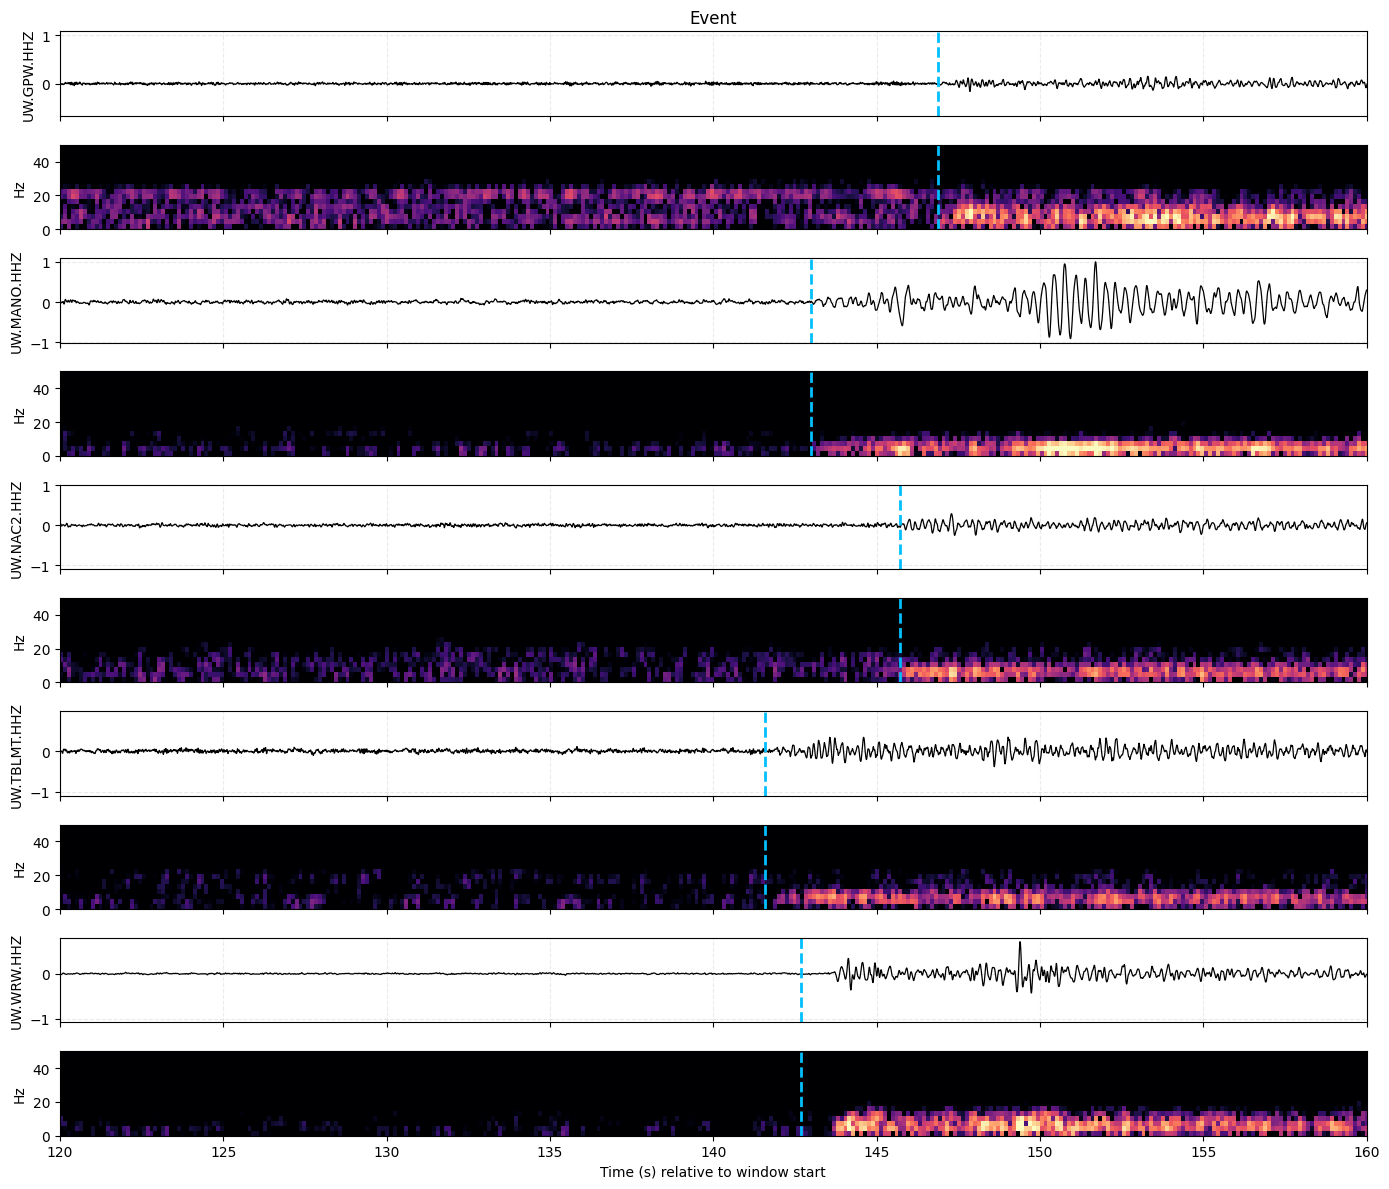

In [165]:
rows = run_download_pick_plot()


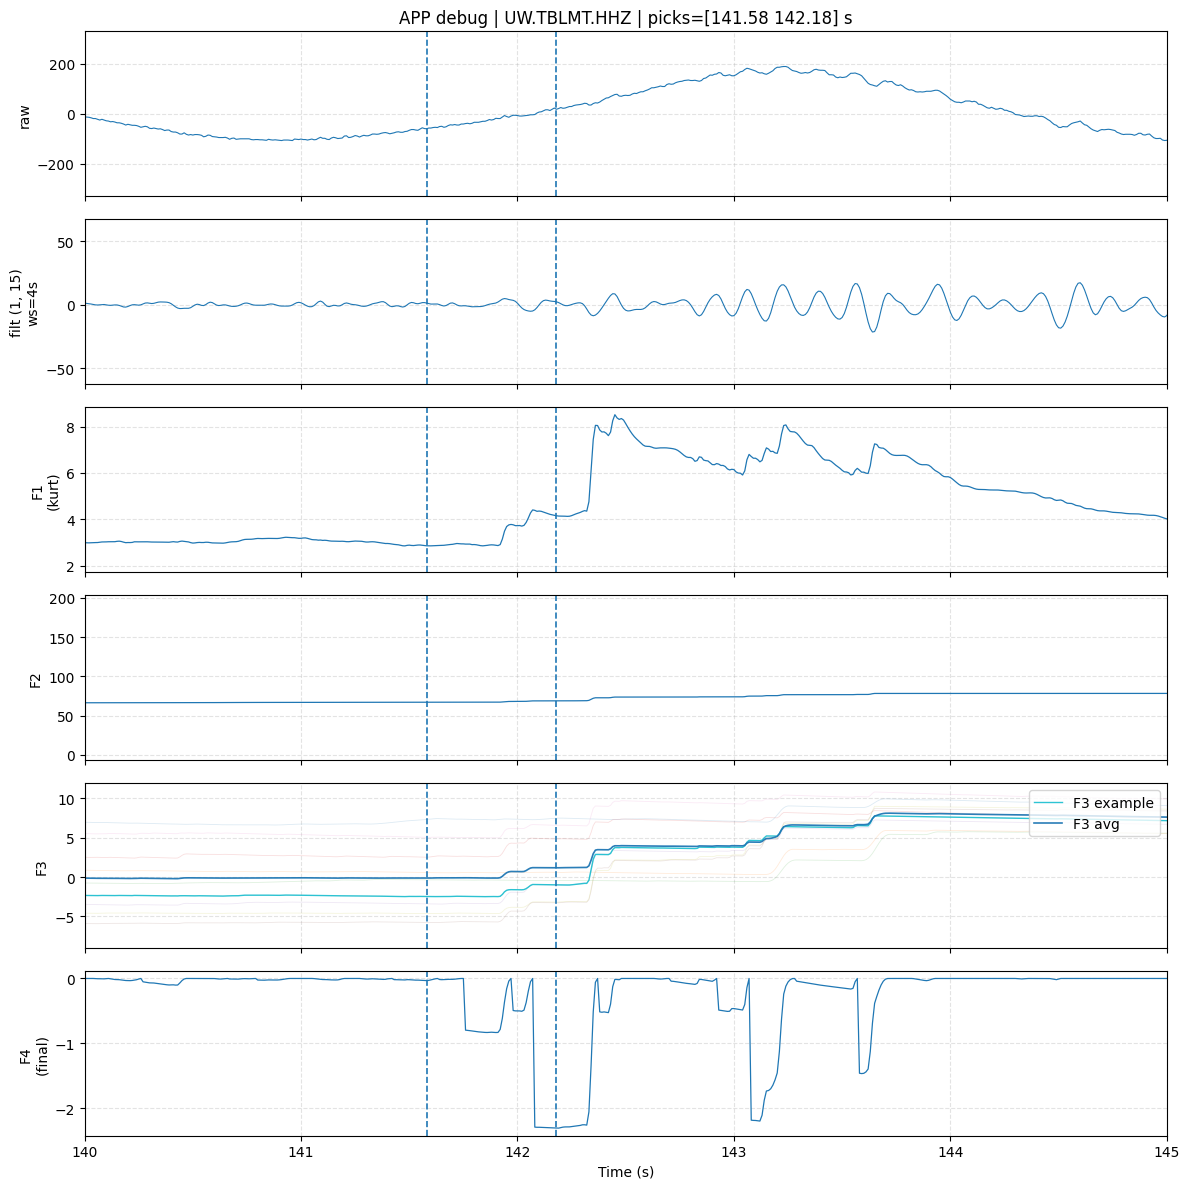

In [177]:
# rows = run_download_pick_plot(...)  # you already ran this

target = "UW.TBLMT"

# 1) find the row
row_wrw = next((r for r in rows if target in r["name"]), None)
if row_wrw is None:
    raise ValueError(f"Could not find {target} in rows. Available names: {[r['name'] for r in rows]}")

# 2) grab its debug dict
dbg_wrw = row_wrw["dbg"]

# 3) make sure picks_t is present for the plot_app_debug function
# (some of our earlier plotting assumes dbg["picks_t"])
if "picks_t" not in dbg_wrw:
    # if you stored picks_t separately in the row, copy it in
    dbg_wrw["picks_t"] = np.array([row_wrw["pick_t"]]) if row_wrw.get("pick_t") is not None else np.array([])

# 4) plot the debug panels INCLUDING all F3s (faint)
plot_app_debug(
    dbg_wrw,
    fs=100.0,                 # or whatever you used
    xlim_s= [140, 145],              # or e.g. (0, 200) or (120, 160)
    title_prefix=f"APP debug | {row_wrw['name']}",
    show_all_f3=True
)
